/home/nakamuraroi/.local/lib/python3.8/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/nakamuraroi/.local/lib/python3.8/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/nakamuraroi/.local/lib/python3.8/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /home/nakamuraroi/.local/lib/python3.8/site-packages/torch_sparse/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "
/home/nakamuraroi/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook imp

Hamiltonian-ODE Dynamic Graph Learning (3D Visualization Ready)
1. データ読み込み開始...
2. 埋め込みベクトルを結合中...
  10000件処理済み...
  20000件処理済み...
  30000件処理済み...
  40000件処理済み...
✓ 前処理完了: 19389 件

[Filtering] 特許を 2 件以上保有する企業を抽出中...
  Total Corporations: 2450 -> Active Corps: 1113
  (削減率: 54.6%)
  Valid Patents: 19389 -> 19363 (企業が残った特許のみ)
Nodes: 20471, Corps: 1113, Dim: 1088
Initializing corporate vectors with patent means...

>>> Training Started...
Epoch 01 | Loss: 43.9547 | MRR: 0.0517 | Consist: 0.967
Epoch 02 | Loss: 38.5992 | MRR: 0.0627 | Consist: 0.981
Epoch 03 | Loss: 44.8992 | MRR: 0.0798 | Consist: 0.986
Epoch 04 | Loss: 51.2480 | MRR: 0.0712 | Consist: 0.982
Epoch 05 | Loss: 60.3483 | MRR: 0.0697 | Consist: 0.978
Epoch 06 | Loss: 58.4806 | MRR: 0.0663 | Consist: 0.985
Epoch 07 | Loss: 55.2099 | MRR: 0.0794 | Consist: 0.988
Epoch 08 | Loss: 52.7921 | MRR: 0.0697 | Consist: 0.988
Epoch 09 | Loss: 51.4276 | MRR: 0.0593 | Consist: 0.988
Epoch 10 | Loss: 50.0761 | MRR: 0.0607 | Consist: 0.987
E

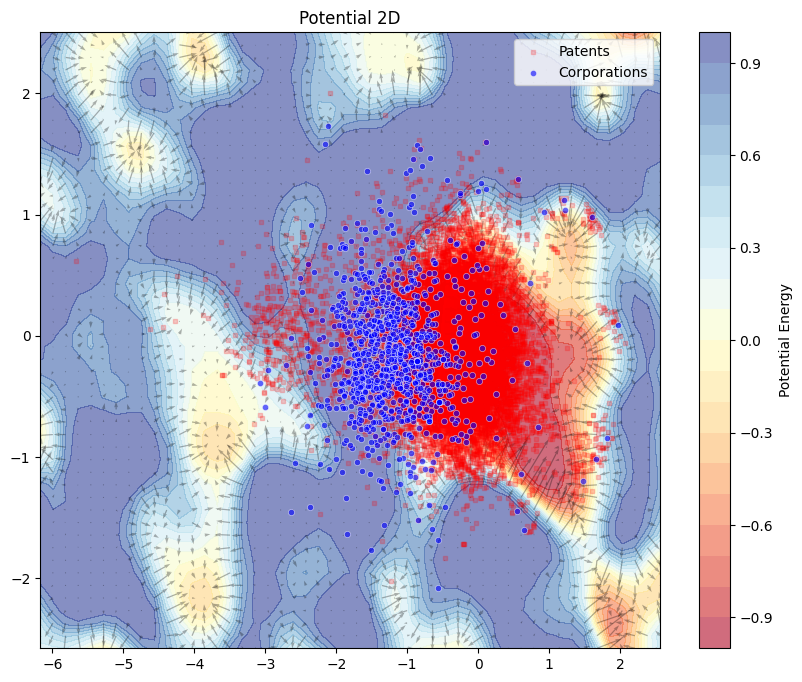

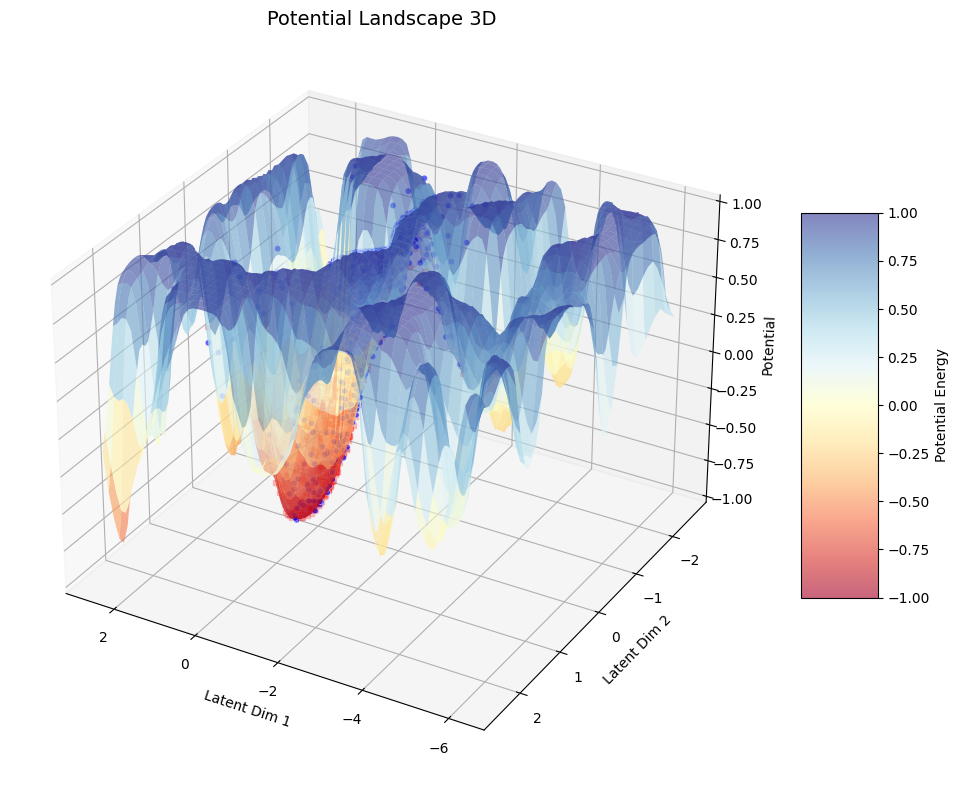

In [1]:
import time
import pandas as pd
import numpy as np
import ast
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint_adjoint as odeint
from torch.optim.lr_scheduler import ReduceLROnPlateau
from collections import Counter
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from mpl_toolkits.mplot3d import Axes3D  # 3Dプロット用

# 基本設定
warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 1. データ前処理
# ============================================================
def safe_parse_embedding(x):
    """埋め込みベクトルの文字列を安全にパースする"""
    if pd.isna(x) or x == "":
        return None
    if isinstance(x, (list, np.ndarray)):
        return np.array(x, dtype=np.float32)
    if isinstance(x, str):
        try:
            s = re.sub(r'[\[\]\n]', '', x)
            s = s.replace(',', ' ')
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except Exception:
            return None
    return None

def preprocess_data(file_path):
    print("1. データ読み込み開始...")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"エラー: ファイル '{file_path}' が見つかりません。")
        return pd.DataFrame()

    print("2. 埋め込みベクトルを結合中...")
    combined_vectors = []
    valid_indices = []
    
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row.get('description_embedding', ''))
        meta = safe_parse_embedding(row.get('metadata_embedding', ''))
        
        if desc is not None and meta is not None:
            if len(desc) > 0 and len(meta) > 0:
                combined_vectors.append(np.concatenate([desc, meta]))
                valid_indices.append(i)
        
        if i % 10000 == 0 and i > 0:
            print(f"  {i}件処理済み...")

    if not combined_vectors:
        print("警告: 有効なベクトルデータがありません。")
        return pd.DataFrame()

    df = df.iloc[valid_indices].copy()
    df['combined_vector'] = combined_vectors
    
    def parse_corp(x):
        try:
            return ast.literal_eval(x) if isinstance(x, str) else x
        except:
            return [x] if isinstance(x, str) else x
    
    if "corporation" in df.columns:
        df["corporation"] = df["corporation"].apply(parse_corp)
        df["corporation"] = df["corporation"].apply(lambda x: x if isinstance(x, list) else [])
    
    if "year_month" in df.columns:
        df['year_month'] = pd.to_datetime(df['year_month'], errors='coerce')
        df = df.dropna(subset=['year_month'])
        df = df[(df['year_month'] >= '2010-01-01') & (df['year_month'] <= '2020-12-31')]
    
    print(f"✓ 前処理完了: {len(df)} 件")
    return df

def filter_active_corporations(df, min_patents=10):
    """
    【新規追加】指定した件数以上の特許を持っている企業のみを残す
    """
    print(f"\n[Filtering] 特許を {min_patents} 件以上保有する企業を抽出中...")
    
    # 1. 全企業の出現回数をカウント
    all_corps_flat = [c for sublist in df['corporation'] for c in sublist]
    corp_counts = Counter(all_corps_flat)
    
    total_corps = len(corp_counts)
    
    # 2. 条件を満たす企業セットを作成
    active_corps = {c for c, n in corp_counts.items() if n >= min_patents}
    
    print(f"  Total Corporations: {total_corps} -> Active Corps: {len(active_corps)}")
    print(f"  (削減率: {100 * (1 - len(active_corps)/total_corps):.1f}%)")
    
    # 3. DataFrame内の企業リストを更新（アクティブな企業だけ残す）
    def filter_row(corp_list):
        return [c for c in corp_list if c in active_corps]
    
    df['corporation'] = df['corporation'].apply(filter_row)
    
    # 4. 企業が0社になってしまった特許（マイナーな企業しか持っていない特許）を除外
    original_len = len(df)
    df = df[df['corporation'].map(len) > 0].copy()
    
    print(f"  Valid Patents: {original_len} -> {len(df)} (企業が残った特許のみ)")
    
    return df

def calculate_initial_corp_vectors(df, num_corps, input_dim, all_corporations):
    """
    企業の初期ベクトルを「保有特許の平均」で計算する関数
    """
    print("Initializing corporate vectors with patent means...")
    corp_vectors = np.zeros((num_corps, input_dim), dtype=np.float32)
    corp_counts = np.zeros(num_corps, dtype=np.float32)
    
    # Corp名 -> Index のマップ
    corp_to_idx = {c: i for i, c in enumerate(all_corporations)}
    
    for _, row in df.iterrows():
        vec = row['combined_vector']
        if vec is None or len(vec) != input_dim: continue
        
        corps = row['corporation']
        for c in corps:
            if c in corp_to_idx:
                idx = corp_to_idx[c]
                corp_vectors[idx] += vec
                corp_counts[idx] += 1
    
    # 平均化 (特許がない企業はゼロのまま、あるいはランダムノイズを加える)
    for i in range(num_corps):
        if corp_counts[i] > 0:
            corp_vectors[i] /= corp_counts[i]
        else:
            # 特許がない場合は小さなランダム値で初期化
            corp_vectors[i] = np.random.normal(0, 0.01, input_dim)
            
    return torch.tensor(corp_vectors, dtype=torch.float32)

# ============================================================
# 2. モデルコンポーネント定義
# ============================================================

# --- GAT Encoder ---
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels * 2, hidden_channels, heads=2, concat=False)
        self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1, concat=False)
        self.conv_mu = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.dropout = nn.Dropout(0.2)
        self.batch_norm1 = nn.BatchNorm1d(hidden_channels * 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.batch_norm1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

# --- PotentialNet (With Grid Computation) ---
class PotentialNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        # Random Fourier Features (RFF) 用の周波数行列
        self.B = nn.Parameter(torch.randn(latent_dim, hidden_dim // 2) * 3.0, requires_grad=False)

        input_features = hidden_dim # sin/cos projectionにより次元が決定
        
        self.net = nn.Sequential(
            nn.Linear(input_features, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Tanh()
        )

    def forward(self, z):
        # 座標 z を高周波空間へ射影
        proj = torch.matmul(z, self.B)
        x = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        return self.net(x)

    def compute_potential_grid(self, x_range, y_range, resolution=50, device='cpu'):
        """グリッド上でポテンシャルを計算"""
        x = torch.linspace(x_range[0], x_range[1], resolution)
        y = torch.linspace(y_range[0], y_range[1], resolution)
        X, Y = torch.meshgrid(x, y, indexing='ij')
        
        # モデル入力用にフラット化
        grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)
        
        # ポテンシャル計算
        model_device = next(self.parameters()).device
        with torch.no_grad():
            potentials = self.forward(grid_points.to(model_device))
        
        return (
            X.cpu().numpy(), 
            Y.cpu().numpy(), 
            potentials.view(resolution, resolution).cpu().numpy()
        )

# --- GradientODEFunc (With Gradient Field Computation) ---
class GradientODEFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        # 勾配フロー: dz/dt = -grad(Phi)
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        
        # tanhで勾配の大きさを制限し、学習を安定化
        return - torch.tanh(self.scale) * grad_z
    
    def compute_gradient_field(self, X, Y, device='cpu'):
        """グリッド上で勾配ベクトル場を計算"""
        grid_points = torch.tensor(
            np.stack([X.flatten(), Y.flatten()], axis=1), 
            dtype=torch.float32, device=device
        )
        grid_points.requires_grad_(True)
        
        phi = self.potential_net(grid_points)
        gradients = torch.autograd.grad(phi.sum(), grid_points, create_graph=False)[0]
        
        # Hamiltonian/Gradient Flowにおける「移動方向」は -gradient
        grad_x = gradients[:, 0].view(X.shape).cpu().numpy()
        grad_y = gradients[:, 1].view(X.shape).cpu().numpy()
        
        return grad_x, grad_y

class GradientNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func = GradientODEFunc(self.potential_net)

    def forward(self, z_current, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        # odeintで積分し、最後の時刻の状態を返す
        z_future = odeint(
            self.ode_func, z_current, t_span,
            method='dopri5', rtol=1e-3, atol=1e-3
        )[-1]
        return z_future

# ============================================================
# 2. 共通モジュール (Encoder / Base Class)
# ============================================================
class SharedEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv_mu = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)
        self.bn = nn.BatchNorm1d(hidden_channels * 2)

    def forward(self, x, edge_index):
        x = F.elu(self.bn(self.conv1(x, edge_index)))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)
    
class BaseDynamicVGAE(nn.Module):
    """全てのモデルの親クラス"""
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        
        # 企業埋め込み
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        
        self.encoder = SharedEncoder(input_dim, hidden_dim, latent_dim)

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        corp_idx = node_indices[node_indices < self.num_corps]
        if corp_idx.numel() > 0:
            features[corp_idx] = self.corp_embeddings(corp_idx)
        return features

    def encode(self, x, edge_index):
        x = self.get_node_features(x)
        mu, logvar = self.encoder(x, edge_index)
        z = mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar) if self.training else mu
        return z, mu, logvar

    def decode(self, z, edge_index):
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        return torch.sigmoid((z_src * z_dst).sum(dim=1))

    def predict_future(self, z_history):
        """モデルごとに実装"""
        raise NotImplementedError

# ============================================================
# 3.4つのモデル定義
# ============================================================
# --- 1. Static VGAE (時間依存なし) ---
class StaticVGAE(BaseDynamicVGAE):
    def predict_future(self, z_history):
        # 予測しない（現在の値をそのまま返す）
        return z_history[-1]

# --- 2. VGRNN (離散時間 / LSTM) ---
class VGRNN(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim)
        self.lstm = nn.LSTM(input_size=latent_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, latent_dim)

    def predict_future(self, z_history):
        # z_history: List of [N, latent_dim] -> Tensor [N, Seq, latent_dim]
        # ノードごとに独立した時系列として扱う
        seq_tensor = torch.stack(z_history, dim=1)
        out, _ = self.lstm(seq_tensor)
        # 最後のタイムステップの出力を使用
        return self.fc_out(out[:, -1, :])

# --- 3. Standard GODE (連続時間 / 物理なし) ---
class ODEFuncNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, latent_dim),
            nn.Tanh()
        )
    
    def forward(self, t, z):
        return self.net(z)

class StandardGODE(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim)
       # 独立したModuleとして定義
        self.ode_func_module = ODEFuncNet(latent_dim, hidden_dim)

    def predict_future(self, z_history):
        z_curr = z_history[-1]
        t_span = torch.tensor([0., 1.0], device=z_curr.device) # 1ステップ先へ
        z_next = odeint(self.ode_func_module, z_curr, t_span, method='rk4', rtol=1e-3, atol=1e-3)[-1]
        return z_next

# --- 4. Proposed (Potential ODE) (連続時間 / 物理あり) ---
class PotentialGradientFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net

    def forward(self, t, z):
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        return -grad_z
    
# --- 4. Proposed (Potential ODE) (連続時間 / 物理あり) ---
class ProposedPotentialODE(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim)
        # ポテンシャル場 Phi(z)
        self.potential_net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
        # ODE関数ラッパーに potential_net を渡す
        self.ode_gradient_module = PotentialGradientFunc(self.potential_net)

    def predict_future(self, z_history):
        z_curr = z_history[-1]
        t_span = torch.tensor([0., 1.0], device=z_curr.device)
        z_next = odeint(self.ode_gradient_module, z_curr, t_span, method='rk4', rtol=1e-3, atol=1e-3)[-1]
        return z_next

# ============================================================
# 4. 学習・評価ロジック
# ============================================================
def compute_metrics(model, z_pred, pos_edge_index, num_corps, num_nodes):
    """AUCと簡易MRRを計算"""
    model.eval()
    
    # 評価対象: 企業->特許のエッジ
    mask = (pos_edge_index[0] < num_corps) & (pos_edge_index[1] >= num_corps)
    eval_edges = pos_edge_index[:, mask]
    if eval_edges.size(1) < 2: return 0.5, 0.0

    # サンプリング数を制限して高速化
    num_samples = min(eval_edges.size(1), 500)
    indices = torch.randperm(eval_edges.size(1))[:num_samples]
    src, dst = eval_edges[0, indices], eval_edges[1, indices]

    # --- AUC ---
    with torch.no_grad():
        pos_scores = model.decode(z_pred, torch.stack([src, dst])).cpu().numpy()
        
        neg_dst = torch.randint(num_corps, num_nodes, src.size(), device=device)
        neg_scores = model.decode(z_pred, torch.stack([src, neg_dst])).cpu().numpy()
    
    y_true = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])
    y_scores = np.concatenate([pos_scores, neg_scores])
    auc = roc_auc_score(y_true, y_scores)

    # --- MRR (簡易版: 1 vs 99) ---
    ranks = []
    with torch.no_grad():
        for s, d, p_score in zip(src, dst, pos_scores):
            # 負例候補99個
            neg_cands = torch.randint(num_corps, num_nodes, (99,), device=device)
            # ターゲット(正解)を追加
            cands = torch.cat([d.view(1), neg_cands])
            src_repeated = s.repeat(100)
            
            all_scores = model.decode(z_pred, torch.stack([src_repeated, cands]))
            # 正解(index 0)よりスコアが高いものの数 + 1
            rank = (all_scores > all_scores[0]).sum().item() + 1
            ranks.append(1.0 / rank)
            
    mrr = np.mean(ranks)
    return auc, mrr

def train_comparison(config, num_epochs=30, latent_dim=16):
    """全モデルを比較学習"""
    models = {
        "Static": StaticVGAE,
        "VGRNN": VGRNN,
        "StandardGODE": StandardGODE,
        "Proposed": ProposedPotentialODE
    }
    
    results = {}
    years = sorted(config['graphs'].keys())
    train_years = years[:-2] # 最後2つを検証用
    
    for name, model_cls in models.items():
        print(f"\n[{name}] Training Start...")
        model = model_cls(config['total_n'], config['num_corps'], config['in_dim'], hidden_dim=64, latent_dim=latent_dim).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)
        
        history = {'loss': [], 'auc': [], 'mrr': []}
        
        for epoch in range(num_epochs):
            model.train()
            epoch_loss = 0
            
            # --- Training Loop ---
            for i in range(len(train_years) - 1):
                y_t = train_years[i]
                y_next = train_years[i+1]
                
                data_t = config['graphs'][y_t].to(device)
                data_next = config['graphs'][y_next].to(device)
                
                # 履歴作成 (過去3ステップ分)
                z_hist = []
                # 直近3つのグラフをEncodeして latent vector を取得
                hist_years = range(max(years[0], y_t - 2), y_t + 1)
                for hy in hist_years:
                    d = config['graphs'][hy].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist.append(z)
                
                # Padding if history is short (for LSTM/RNN consistency)
                while len(z_hist) < 3:
                    z_hist.insert(0, z_hist[0]) 

                optimizer.zero_grad()
                
                # 1. Reconstruction Loss (Current Time)
                z_t = z_hist[-1] # Current latent
                pos_pred = model.decode(z_t, data_t.edge_index)
                neg_idx = torch.randint(0, model.num_nodes, data_t.edge_index.size(), device=device)
                neg_pred = model.decode(z_t, neg_idx)
                recon_loss = -torch.log(pos_pred + 1e-9).mean() - torch.log(1 - neg_pred + 1e-9).mean()
                
                # 2. Future Prediction Loss
                loss_pred = torch.tensor(0.0, device=device)
                loss_pot = torch.tensor(0.0, device=device)
                
                if name != "Static":
                    # 未来予測 z_pred
                    z_pred = model.predict_future(z_hist)
                    # 正解データの分布 (mu)
                    with torch.no_grad():
                        _, mu_next, _ = model.encode(data_next.x, data_next.edge_index)
                    
                    # MSEで予測誤差を最小化
                    mask = data_next.active_mask
                    loss_pred = F.mse_loss(z_pred[mask], mu_next[mask])
                
                # 3. Potential Loss (Proposed Only)
                if name == "Proposed":
                    # リンクされているペアのポテンシャルエネルギーを下げる
                    phi = model.potential_net(z_t)
                    src, dst = data_t.edge_index
                    
                    # (A) 正例のポテンシャルエネルギー (つながっているペア)
                    pos_pot = phi[src] + phi[dst]
                    
                    # (B) 負例のポテンシャルエネルギー (ランダムなペア)
                    # 相手(dst)をランダムに入れ替えて作成
                    perm = torch.randperm(dst.size(0))
                    neg_dst = dst[perm]
                    neg_pot = phi[src] + phi[neg_dst]
                    
                    # (C) マージン損失: 「正例 < 負例 - マージン」になるように学習
                    # relu(正例 - 負例 + 0.1) -> 負例が正例より十分大きくないと罰則
                    loss_pot = torch.relu(pos_pot - neg_pot + 0.1).mean()
                    
                    # (D) 正則化: phiの絶対値が大きくなりすぎないように抑制
                    loss_pot += 0.01 * (phi ** 2).mean()
                
                total_loss = recon_loss + loss_pred + loss_pot
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                epoch_loss += total_loss.item()

            avg_loss = epoch_loss / (len(train_years) - 1)
            history['loss'].append(avg_loss)
            
            # --- Validation Loop ---
            model.eval()
            # 検証: 最後から2番目の年から、最後の年を予測
            val_t = years[-2]
            val_next = years[-1]
            
            # Validation用履歴作成
            z_hist_val = []
            hist_years = range(max(years[0], val_t - 2), val_t + 1)
            for hy in hist_years:
                d = config['graphs'][hy].to(device)
                with torch.no_grad():
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
            while len(z_hist_val) < 3: z_hist_val.insert(0, z_hist_val[0])
            
            with torch.no_grad():
                z_pred_val = model.predict_future(z_hist_val)
                auc, mrr = compute_metrics(model, z_pred_val, config['graphs'][val_next].edge_index.to(device),
                                           config['num_corps'], config['total_n'])
            
            history['auc'].append(auc)
            history['mrr'].append(mrr)
            
            print(f"  Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | AUC: {auc:.4f} | MRR: {mrr:.4f}")
            
        results[name] = history
        
    return results

# ============================================================
# 3. 統合モデル (UnifiedVGAE)
# ============================================================
class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=256,
                 latent_dim=2, sequence_length=3, initial_corp_vectors=None):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        
        # 企業用埋め込み設定
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        if initial_corp_vectors is not None:
            # 【変更点】計算済みの平均ベクトルで初期化
            self.corp_embeddings.weight.data.copy_(initial_corp_vectors)
        else:
            nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)

        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        corp_idx = node_indices[node_indices < self.num_corps]
        if corp_idx.numel() > 0:
            features[corp_idx] = self.corp_embeddings(corp_idx)
        return features

    def encode(self, x, edge_index, node_indices=None):
        x_features = self.get_node_features(x, node_indices)
        mu, logvar = self.encoder(x_features, edge_index)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)
        return mu

    def decode(self, z, edge_index):
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        # 内積を計算
        logits = (z_src * z_dst).sum(dim=1)
        # 値を -10 ~ 10 にクリップして、シグモイドの飽和（常に1.0になる現象）を防ぐ
        logits = torch.clamp(logits, -10, 10)
        return torch.sigmoid(logits)
    
    def predict_future(self, z_history_list):
        # 最新の潜在変数からODEで未来へ飛ばす
        return self.temporal_predictor(z_history_list[-1])

# ============================================================
# 4. 損失関数と補助関数
# ============================================================
def sample_hard_negatives_v2(model, z, active_corps, active_patents, 
                             pos_set, historical_edges, num_samples=1000):
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    neg_edges = []
    # ランダム候補生成
    cand_c = active_corps[torch.randint(0, len(active_corps), (num_samples * 5,))]
    cand_p = active_patents[torch.randint(0, len(active_patents), (num_samples * 5,))]

    # 距離計算 (近いのにリンクがないペアを探す)
    dists = torch.norm(z[cand_c] - z[cand_p], dim=1)
    sorted_indices = torch.argsort(dists)
    
    for idx in sorted_indices:
        c, p = cand_c[idx].item(), cand_p[idx].item()
        edge = (c, p)
        if edge not in pos_set and edge not in historical_edges:
            neg_edges.append([c, p])
            if len(neg_edges) >= num_samples:
                break
                
    if not neg_edges:
        return None
    return torch.tensor(neg_edges, dtype=torch.long, device=z.device).t().contiguous()

def compute_loss_standardized(model, data_t, data_t1, num_corps, z_history_for_prediction,
                              historical_edges, beta=0.01, pos_weight=5.0, 
                              latent_pred_weight=1.0, future_link_weight=10.0,
                              potential_weight=0.1, repulsion_weight=0.0): 
    device = data_t.x.device
    node_indices = torch.arange(model.num_nodes, device=device)
    patent_mask = (node_indices >= num_corps) & data_t.active_mask
    
    # 1. エンコード
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
    
    # 2. 再構成損失
    pos_edge_index = data_t.edge_index
    active_corps = torch.unique(pos_edge_index[0][pos_edge_index[0] < num_corps])
    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_corps])
    pos_set = set(tuple(p.tolist()) for p in pos_edge_index.t())
    
    neg_edge_index = sample_hard_negatives_v2(model, z_t, active_corps, active_patents, 
                                                pos_set, historical_edges, num_samples=500)
    
    recon_loss = torch.tensor(0.0, device=device)
    if neg_edge_index is not None:
        pos_pred = model.decode(z_t, pos_edge_index)
        neg_pred = model.decode(z_t, neg_edge_index)
        
        recon_loss = -(torch.log(pos_pred + 1e-15)).mean() * pos_weight \
                     - torch.log(1 - neg_pred + 1e-15).mean()

    # KL損失
    kl_loss = -0.5 * torch.mean(1 + logvar_t[data_t.active_mask] - mu_t[data_t.active_mask].pow(2) - logvar_t[data_t.active_mask].exp())

    # === 3. ポテンシャル学習 ===
    potential_loss = torch.tensor(0.0, device=device)
    has_potential = hasattr(model.temporal_predictor, 'potential_net')
    
    if potential_weight > 0 and has_potential:
        # 安定化のため mu_t を使用
        phi = model.temporal_predictor.potential_net(mu_t)
        src, dst = data_t.edge_index
        
        # (A) 正例のポテンシャル
        pos_pot = phi[src] + phi[dst]
        
        # (B) 負例のポテンシャル (ランダムペア)
        perm = torch.randperm(dst.size(0))
        neg_dst = dst[perm]
        neg_pot = phi[src] + phi[neg_dst]
        
        # (C) マージン損失 + 正則化
        loss_contrastive = torch.relu(pos_pot - neg_pot + 0.1).mean()
        loss_reg = 0.01 * (phi ** 2).mean()
        
        potential_loss = loss_contrastive + loss_reg

    # 4. 未来予測 (ODE)
    z_t1_pred = model.predict_future(z_history_for_prediction)
    with torch.no_grad():
        _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)
    latent_pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])

    # 5. 未来リンク予測
    future_link_loss = torch.tensor(0.0, device=device)
    pos_edge_index_t1 = data_t1.edge_index
    if pos_edge_index_t1.size(1) > 0:
        active_c_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
        active_p_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
        pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
        
        neg_t1 = sample_hard_negatives_v2(model, z_t1_pred, active_c_t1, active_p_t1, pos_set_t1, historical_edges, num_samples=300)
        if neg_t1 is not None:
            future_link_loss = -torch.log(model.decode(z_t1_pred, pos_edge_index_t1) + 1e-15).mean() * pos_weight - \
                               torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()

    # 6. 反発力損失 (特許間が近づきすぎないように)
    repulsion_loss = torch.tensor(0.0, device=device)
    
    z_patents = z_t[patent_mask]
    if z_patents.size(0) > 100: # 計算負荷軽減のためサンプリングまたは条件付き
        idx_sub = torch.randperm(z_patents.size(0))[:200]
        z_sub = z_patents[idx_sub]
        dist_matrix = torch.cdist(z_sub, z_sub)
        eye_mask = ~torch.eye(dist_matrix.size(0), dtype=torch.bool, device=device)
        repulsion_loss = torch.relu(0.5 - dist_matrix[eye_mask]).mean()

    total_loss = (recon_loss + beta * kl_loss + latent_pred_weight * latent_pred_loss + 
                  future_link_weight * future_link_loss + potential_weight * potential_loss + 
                  repulsion_weight * repulsion_loss)
    
    return total_loss, {
        'total': total_loss.item(), 'potential': potential_loss.item(), 
        'future': future_link_loss.item(), 'repulsion': repulsion_loss.item()
    }

def calculate_evidence_metrics(model, data_t, z_now, z_future):
    """モデルの物理的な妥当性を示す指標を計算"""
    model.eval()
    active_mask = data_t.active_mask
    z_active = z_now[active_mask]
    z_fut_active = z_future[active_mask]
    
    # 1. 空間分散度
    centroid = z_active.mean(dim=0)
    dispersion = torch.mean(torch.sum((z_active - centroid)**2, dim=1)).item()
    
    # 2. 物理的一致度 (Cosine Sim between Actual Move & Gradient)
    v_actual = z_fut_active - z_active
    z_req = z_active.detach().clone().requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = model.temporal_predictor.potential_net(z_req)
        # Gradient Flow: v = -grad(Phi)
        v_theoretical = -torch.autograd.grad(phi.sum(), z_req)[0]
    
    cos_sim = F.cosine_similarity(v_actual, v_theoretical, dim=1)
    avg_consistency = cos_sim.mean().item()
    
    return {"dispersion": dispersion, "consistency": avg_consistency}

# ============================================================
# 5. 評価関数 (MRR / Hits@K)
# ============================================================
def compute_ranking_metrics(model, z_pred, pos_edge_index, num_corps, all_true_edges):
    model.eval()
    if pos_edge_index.size(1) == 0: return None
    
    # 企業 -> 特許 のエッジのみ抽出
    mask = (pos_edge_index[0] < num_corps) & (pos_edge_index[1] >= num_corps)
    eval_edges = pos_edge_index[:, mask]
    if eval_edges.size(1) == 0: return None
    
    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_corps])
    if len(active_patents) < 2: return None
    
    reciprocal_ranks = []
    hits_at_10 = []
    
    # 高速化のためサンプリング評価
    num_eval = min(eval_edges.size(1), 300)
    indices = torch.randperm(eval_edges.size(1))[:num_eval]
    
    for idx in indices:
        src, dst = eval_edges[0, idx].item(), eval_edges[1, idx].item()
        
        neg_candidates = []
        while len(neg_candidates) < 99:
            neg = active_patents[torch.randint(len(active_patents), (1,))].item()
            if neg != dst and (src, neg) not in all_true_edges:
                neg_candidates.append(neg)
        
        targets = [dst] + neg_candidates
        src_repeated = torch.tensor([src] * len(targets), device=z_pred.device)
        dst_tensor = torch.tensor(targets, device=z_pred.device)
        
        with torch.no_grad():
            scores = model.decode(z_pred, torch.stack([src_repeated, dst_tensor]))
        
        rank = (scores > scores[0]).sum().item() + 1
        reciprocal_ranks.append(1.0 / rank)
        hits_at_10.append(1.0 if rank <= 10 else 0.0)
        
    return {'mrr': np.mean(reciprocal_ranks), 'hits@10': np.mean(hits_at_10)}

# ============================================================
# 6. 学習ループ
# ============================================================
def train_model_improved(model, global_graph_dict, num_corps, historical_edges, num_epochs=20):
    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    
    years = sorted(global_graph_dict.keys())
    train_years = years[:int(len(years) * 0.75)]
    val_years = years[int(len(years) * 0.75):]
    
    history = {'train_loss': [], 'val_mrr': [], 'dispersion': [], 'consistency': []}
    
    all_true_edges = set()
    for y in years:
        all_true_edges.update([tuple(e) for e in global_graph_dict[y].edge_index.t().tolist()])
    
    best_mrr = 0.0
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        # --- Train ---
        for i in range(len(train_years) - 1):
            year_t = train_years[i]
            year_t1 = train_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 履歴zの構築
            z_history = []
            for j in range(max(0, i - 2), i + 1):
                with torch.no_grad():
                    d = global_graph_dict[train_years[j]].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_history.append(z)
            
            optimizer.zero_grad()
            loss, _ = compute_loss_standardized(model, data_t, data_t1, num_corps, z_history, historical_edges, potential_weight=0.01)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            
            # 最終ステップでエビデンス計算
            if i == len(train_years) - 2:
                with torch.no_grad():
                    z_t = z_history[-1]
                    z_pred = model.predict_future(z_history)
                    metrics = calculate_evidence_metrics(model, data_t, z_t, z_pred)
                    history['dispersion'].append(metrics['dispersion'])
                    history['consistency'].append(metrics['consistency'])

        avg_loss = epoch_loss / len(train_years)
        history['train_loss'].append(avg_loss)
        
        # --- Validation ---
        model.eval()
        val_mrr_list = []
        for i in range(len(val_years) - 1):
            year_t = val_years[i]
            year_t1 = val_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 検証用の履歴構築
            z_hist_val = []
            for y in [py for py in years if py <= year_t][-3:]:
                 with torch.no_grad():
                    d = global_graph_dict[y].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
            
            with torch.no_grad():
                z_pred = model.predict_future(z_hist_val)
                res = compute_ranking_metrics(model, z_pred, data_t1.edge_index, num_corps, all_true_edges)
                if res: val_mrr_list.append(res['mrr'])

        val_mrr = np.mean(val_mrr_list) if val_mrr_list else 0.0
        history['val_mrr'].append(val_mrr)
        
        scheduler.step(val_mrr)
        if val_mrr > best_mrr: best_mrr = val_mrr
        
        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | MRR: {val_mrr:.4f} | "
              f"Consist: {history['consistency'][-1]:.3f}")

    return model, best_mrr, history

# ============================================================
# 7. 可視化関数 (2D & 3D)
# ============================================================
def visualize_potential_landscape_2d(model, data, num_corps, device, title="Potential 2D"):
    """2D Contour Plot + Vector Field"""
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()
        
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # グリッド計算
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=50, device=device
    )
    
    # 勾配場計算
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    levels = np.linspace(-1.0, 1.0, 21)
    contour = ax.contourf(X, Y, Z, levels=20, cmap='RdYlBu', alpha=0.6)
    plt.colorbar(contour, label='Potential Energy')
    
    # ベクトル場 (-gradient = movement direction)
    ax.quiver(X, Y, -grad_x, -grad_y, color='black', alpha=0.3, width=0.002)
    
    # Scatter
    z_c = z_np[:num_corps]
    z_p = z_np[num_corps:]
    ax.scatter(z_p[:, 0], z_p[:, 1], c='red', marker='s', s=10, alpha=0.2, label='Patents')
    ax.scatter(z_c[:, 0], z_c[:, 1], c='blue', marker='o',s=20, edgecolors='white', linewidth = 0.5, alpha=0.6, label='Corporations')
    
    ax.set_title(title)
    ax.legend()
    plt.show()

def visualize_potential_landscape_3d(model, data, num_corps, device, title="Potential Landscape 3D"):
    """
    3D Surface Plot
    ポテンシャル地形を立体的に表示し、ノードの配置を確認する
    """
    
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()

    # 範囲設定
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # 高解像度グリッド
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=80, device=device
    )

    # 2. 勾配(ベクトル)の計算 【追加箇所】
    # 2Dと同様に勾配場を計算します
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)
    
    # ODEのダイナミクスは -grad (坂を下る方向) なので符号反転
    U = -grad_x
    V = -grad_y
    # Z方向の矢印成分は0にします（「平面上の移動方向」を示したいため水平に描画）
    W = np.zeros_like(U) 

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 1. 地形のプロット (Surface)
    # cmap='viridis' や 'RdYlBu_r' (逆転) を使用して、低い場所(谷)を見やすくする
    surf = ax.plot_surface(X, Y, Z, cmap='RdYlBu', vmin=-1.0, vmax=1.0,edgecolor='none', alpha=0.6)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Potential Energy')

    # 2. ノードのプロット (Scatter 3D)
    # ノードの高さ(Z座標)は、その位置でのポテンシャル値にする
    with torch.no_grad():
        potentials_nodes = model.temporal_predictor.potential_net(z).cpu().numpy().flatten()
    
    # 特許 (黒/グレー)
    z_p = z_np[num_corps:]
    pot_p = potentials_nodes[num_corps:]
    # 数が多い場合はサンプリングして表示
    if len(z_p) > 500:
        idx = np.random.choice(len(z_p), 500, replace=False)
        z_p = z_p[idx]
        pot_p = pot_p[idx]
        
    ax.scatter(z_p[:, 0], z_p[:, 1], pot_p, c='red', marker='s', s=10, alpha=0.2, label='Patents')

    # 企業 (赤)
    z_c = z_np[:num_corps]
    pot_c = potentials_nodes[:num_corps]
    ax.scatter(z_c[:, 0], z_c[:, 1], pot_c, c='blue', marker='o', s=20, edgecolors='white', linewidth = 0.5, alpha=0.6, label='Corporations')

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Latent Dim 1')
    ax.set_ylabel('Latent Dim 2')
    ax.set_zlabel('Potential')
    
    # Z軸の範囲を設定
    ax.set_zlim(-1.0, 1.0)
    # 視点の調整 (必要に応じて変更)
    ax.view_init(elev=30, azim=120)
    plt.show()

def build_global_graphs(df):
    """グラフ構築関数（以前のバージョンと同じ）"""
    all_corporations = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    
    corp_to_idx = {corp: i for i, corp in enumerate(all_corporations)}
    patent_to_idx = {patent: i + len(all_corporations) for i, patent in enumerate(all_patents)}
    total_nodes = len(all_corporations) + len(all_patents)
    
    patent_features = {}
    for _, row in df.iterrows():
        patent_features[row['patent_number']] = row['combined_vector']
    
    input_dim = len(next(iter(patent_features.values()))) if patent_features else 10

    global_graph_dict = {}
    year_groups = df.groupby(df['year_month'].dt.year)
    all_historical_edges = set()
    
    for year, group in year_groups:
        edges = []
        for _, row in group.iterrows():
            if row['patent_number'] not in patent_to_idx: continue
            p_idx = patent_to_idx[row['patent_number']]
            for corp in row['corporation']:
                if corp in corp_to_idx:
                    c_idx = corp_to_idx[corp]
                    edges.append([c_idx, p_idx]) # Corp -> Patent
                    edges.append([p_idx, c_idx]) # Patent -> Corp
                    all_historical_edges.add((c_idx, p_idx))
        
        if not edges: continue
        
        x = torch.zeros(total_nodes, input_dim)
        for p_num, p_idx in patent_to_idx.items():
            if p_num in patent_features: x[p_idx] = torch.tensor(patent_features[p_num])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[torch.unique(edge_index)] = True
        
        global_graph_dict[year] = Data(x=x, edge_index=edge_index, active_mask=active_mask, num_nodes=total_nodes)
        
    return global_graph_dict, all_corporations, all_patents, total_nodes, all_historical_edges, input_dim

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    print("=" * 60)
    print("Hamiltonian-ODE Dynamic Graph Learning (3D Visualization Ready)")
    print("=" * 60)
    
    # 1. データ準備
    df = preprocess_data('../dataset/topic_info3.csv')
    if len(df) == 0: exit()

    df = filter_active_corporations(df, min_patents=2)
    
    # 2. グラフ構築
    graphs, corps, patents, total_n, hist_edges, in_dim = build_global_graphs(df)
    num_corps = len(corps)
    print(f"Nodes: {total_n}, Corps: {num_corps}, Dim: {in_dim}")

    # 初期ベクトルの計算
    init_vectors = calculate_initial_corp_vectors(df, num_corps, in_dim, corps)

    # 3. モデル初期化
    model = UnifiedVGAE(
        num_nodes=total_n, num_corps=num_corps, input_dim=in_dim,
        hidden_dim=128, latent_dim=2, 
        initial_corp_vectors=init_vectors
    ).to(device)

    # 4. 学習
    print("\n>>> Training Started...")
    model, best_mrr, history = train_model_improved(
        model, graphs, num_corps, hist_edges, num_epochs=15
    )
    
    print(f"\nTraining Completed. Best MRR: {best_mrr:.4f}")
    
    # 5. 可視化
    last_year = max(graphs.keys())
    print(f"\n[Visualization] Year: {last_year}")
    
    # 2D Plot
    visualize_potential_landscape_2d(model, graphs[last_year], num_corps, device)
    
    # 3D Plot
    visualize_potential_landscape_3d(model, graphs[last_year], num_corps, device)

In [ ]:
import optuna
import time
import pandas as pd
import numpy as np
import ast
import copy
import re
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint_adjoint as odeint
from collections import Counter
import warnings
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy.stats as stats
from sklearn.metrics import roc_auc_score

# ============================================================
# 0. 基本設定 & Nature Style Plot Configuration
# ============================================================
warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_nature_style():
    try:
        plt.style.use('seaborn-v0_8-paper')
    except:
        pass 
    mpl.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 7,          
        'axes.labelsize': 8,
        'axes.titlesize': 8,
        'legend.fontsize': 7,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'lines.markersize': 3,
        'savefig.dpi': 300,      
        'figure.figsize': (3.5, 2.5), 
        'axes.spines.top': False,     
        'axes.spines.right': False,   
    })

NATURE_COLORS = {
    "Static": "#808080",       # グレー
    "VGRNN": "#E69F00",        # オレンジ
    "StandardGODE": "#56B4E9", # スカイブルー
    "P-NODE": "#D55E00"        # バーミリオン（提案手法）
}

# ============================================================
# 1. データ前処理
# ============================================================
def safe_parse_embedding(x):
    if pd.isna(x) or x == "": return None
    if isinstance(x, (list, np.ndarray)): return np.array(x, dtype=np.float32)
    if isinstance(x, str):
        try:
            s = re.sub(r'[\[\]\n]', '', x).replace(',', ' ')
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except: return None
    return None

def preprocess_data(file_path):
    print("1. データ読み込み開始...")
    try: df = pd.read_csv(file_path)
    except: return pd.DataFrame()

    combined_vectors = []
    valid_indices = []
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row.get('description_embedding', ''))
        meta = safe_parse_embedding(row.get('metadata_embedding', ''))
        if desc is not None and meta is not None and len(desc)>0 and len(meta)>0:
            combined_vectors.append(np.concatenate([desc, meta]))
            valid_indices.append(i)
    if not combined_vectors: return pd.DataFrame()
    df = df.iloc[valid_indices].copy()
    df['combined_vector'] = combined_vectors
    
    def parse_corp(x):
        try: return ast.literal_eval(x) if isinstance(x, str) else x
        except: return [x] if isinstance(x, str) else x
    
    if "corporation" in df.columns:
        df["corporation"] = df["corporation"].apply(parse_corp)
        df["corporation"] = df["corporation"].apply(lambda x: x if isinstance(x, list) else [])
    if "year_month" in df.columns:
        df['year_month'] = pd.to_datetime(df['year_month'], errors='coerce')
        df = df.dropna(subset=['year_month'])
        df = df[(df['year_month'] >= '2010-01-01') & (df['year_month'] <= '2020-12-31')]
    return df

def filter_active_corporations(df, min_patents=10):
    all_corps_flat = [c for sublist in df['corporation'] for c in sublist]
    corp_counts = Counter(all_corps_flat)
    active_corps = {c for c, n in corp_counts.items() if n >= min_patents}
    df['corporation'] = df['corporation'].apply(lambda x: [c for c in x if c in active_corps])
    df = df[df['corporation'].map(len) > 0].copy()
    return df

def build_global_graphs(df):
    all_corporations = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    corp_to_idx = {corp: i for i, corp in enumerate(all_corporations)}
    patent_to_idx = {patent: i + len(all_corporations) for i, patent in enumerate(all_patents)}
    total_nodes = len(all_corporations) + len(all_patents)
    
    patent_features = {row['patent_number']: row['combined_vector'] for _, row in df.iterrows()}
    input_dim = len(next(iter(patent_features.values()))) if patent_features else 10

    global_graph_dict = {}
    all_historical_edges = set()
    for year, group in df.groupby(df['year_month'].dt.year):
        edges = []
        for _, row in group.iterrows():
            if row['patent_number'] not in patent_to_idx: continue
            p_idx = patent_to_idx[row['patent_number']]
            for corp in row['corporation']:
                if corp in corp_to_idx:
                    c_idx = corp_to_idx[corp]
                    edges.extend([[c_idx, p_idx], [p_idx, c_idx]])
                    all_historical_edges.add((c_idx, p_idx))
        if not edges: continue
        
        x = torch.zeros(total_nodes, input_dim)
        for p_num, p_idx in patent_to_idx.items():
            if p_num in patent_features: x[p_idx] = torch.tensor(patent_features[p_num])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[torch.unique(edge_index)] = True
        global_graph_dict[year] = Data(x=x, edge_index=edge_index, active_mask=active_mask, num_nodes=total_nodes)
        
    return global_graph_dict, all_corporations, all_patents, total_nodes, all_historical_edges, input_dim

def calculate_initial_corp_vectors(df, num_corps, input_dim, all_corporations):
    corp_vectors = np.zeros((num_corps, input_dim), dtype=np.float32)
    corp_counts = np.zeros(num_corps, dtype=np.float32)
    corp_to_idx = {c: i for i, c in enumerate(all_corporations)}
    for _, row in df.iterrows():
        vec = row['combined_vector']
        if vec is None or len(vec) != input_dim: continue
        for c in row['corporation']:
            if c in corp_to_idx:
                idx = corp_to_idx[c]
                corp_vectors[idx] += vec
                corp_counts[idx] += 1
    for i in range(num_corps):
        if corp_counts[i] > 0: corp_vectors[i] /= corp_counts[i]
        else: corp_vectors[i] = np.random.normal(0, 0.01, input_dim)
    return torch.tensor(corp_vectors, dtype=torch.float32)

# ============================================================
# 2. モデルコンポーネント定義
# ============================================================
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv_mu = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)
        self.bn = nn.BatchNorm1d(hidden_channels * 2)

    def forward(self, x, edge_index):
        x = F.elu(self.bn(self.conv1(x, edge_index)))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

class PotentialNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.B = nn.Parameter(torch.randn(latent_dim, hidden_dim // 2) * 3.0, requires_grad=False)
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 2), nn.LeakyReLU(0.2), nn.Dropout(0.1),
            nn.Linear(hidden_dim * 2, hidden_dim), nn.LeakyReLU(0.2), nn.Linear(hidden_dim, 1), nn.Tanh()
        )
    def forward(self, z):
        proj = torch.matmul(z, self.B)
        return self.net(torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1))

class GradientODEFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))
    def forward(self, t, z):
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        return - torch.tanh(self.scale) * grad_z

# ============================================================
# 3. 比較用モデル定義 (Base & 4 Variants)
# ============================================================
class BaseDynamicVGAE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=128, latent_dim=16, initial_corp_vectors=None):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        if initial_corp_vectors is not None:
            self.corp_embeddings.weight.data.copy_(initial_corp_vectors)
        else:
            nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
            
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        # コサイン類似度のスケール（温度）を学習可能にする
        self.logit_scale = nn.Parameter(torch.tensor(2.0))

    def encode(self, x, edge_index):
        features = x.clone()
        node_indices = torch.arange(self.num_nodes, device=x.device)
        corp_idx = node_indices[node_indices < self.num_corps]
        if corp_idx.numel() > 0: features[corp_idx] = self.corp_embeddings(corp_idx)
        mu, logvar = self.encoder(features, edge_index)
        z = mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar) if self.training else mu
        return z, mu, logvar

    def decode(self, z, edge_index):
        z_src, z_dst = z[edge_index[0]], z[edge_index[1]]
        cos_sim = F.cosine_similarity(z_src, z_dst, dim=1)
        scale = F.relu(self.logit_scale) + 1e-3
        return torch.sigmoid(cos_sim * scale)

    def predict_future(self, z_history):
        raise NotImplementedError

# 1. Static VGAE
class StaticVGAE(BaseDynamicVGAE):
    def predict_future(self, z_history): return z_history[-1]

# 2. VGRNN
class VGRNN(BaseDynamicVGAE):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        latent_dim = kwargs.get('latent_dim', 16)
        hidden_dim = kwargs.get('hidden_dim', 128)
        self.lstm = nn.LSTM(latent_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, latent_dim)
    def predict_future(self, z_history):
        out, _ = self.lstm(torch.stack(z_history, dim=1))
        return self.fc(out[:, -1, :])

# 3. Standard GODE
class StandardODEFunc(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), 
            nn.Tanh(), 
            nn.Linear(hidden_dim, latent_dim), 
            nn.Tanh()
        )
    
    def forward(self, t, z):
        return self.net(z)
    
class StandardGODE(BaseDynamicVGAE):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        ld = kwargs.get('latent_dim', 16)
        hd = kwargs.get('hidden_dim', 128)
        # nn.Moduleとして初期化
        self.ode_func = StandardODEFunc(ld, hd)
        
    def predict_future(self, z_history):
        t_span = torch.tensor([0., 1.0], device=z_history[-1].device)
        return odeint(self.ode_func, z_history[-1], t_span)[-1]

# 4. Proposed (P-NODE)
class ProposedPotentialODE(BaseDynamicVGAE):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.potential_net = PotentialNet(kwargs.get('latent_dim', 16), kwargs.get('hidden_dim', 128))
        self.ode_func = GradientODEFunc(self.potential_net)
    def predict_future(self, z_history):
        return odeint(self.ode_func, z_history[-1], torch.tensor([0., 1.0], device=z_history[-1].device))[-1]


# ============================================================
# 4. 損失関数と評価関数
# ============================================================
def sample_hard_negatives_v2(model, z, active_corps, active_patents, pos_set, historical_edges, num_samples=500):
    if len(active_corps) == 0 or len(active_patents) == 0: return None
    cand_c = active_corps[torch.randint(0, len(active_corps), (num_samples * 2,))]
    cand_p = active_patents[torch.randint(0, len(active_patents), (num_samples * 2,))]
    dists = torch.norm(z[cand_c] - z[cand_p], dim=1)
    sorted_indices = torch.argsort(dists)
    
    neg_edges = []
    for idx in sorted_indices:
        c, p = cand_c[idx].item(), cand_p[idx].item()
        if (c, p) not in pos_set and (c, p) not in historical_edges:
            neg_edges.append([c, p])
            if len(neg_edges) >= num_samples: break
    if not neg_edges: return None
    return torch.tensor(neg_edges, dtype=torch.long, device=z.device).t().contiguous()

def compute_ranking_metrics(model, z_pred, pos_edge_index, num_corps, all_true_edges):
    model.eval()
    mask = (pos_edge_index[0] < num_corps) & (pos_edge_index[1] >= num_corps)
    eval_edges = pos_edge_index[:, mask]
    if eval_edges.size(1) == 0: return None
    
    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_corps])
    if len(active_patents) < 2: return None
    
    reciprocal_ranks = []
    hits_at_10 = []
    num_eval = min(eval_edges.size(1), 300)
    indices = torch.randperm(eval_edges.size(1))[:num_eval]
    
    for idx in indices:
        src, dst = eval_edges[0, idx].item(), eval_edges[1, idx].item()
        neg_candidates = []
        while len(neg_candidates) < 99:
            neg = active_patents[torch.randint(len(active_patents), (1,))].item()
            if neg != dst and (src, neg) not in all_true_edges:
                neg_candidates.append(neg)
        
        targets = [dst] + neg_candidates
        src_repeated = torch.tensor([src] * len(targets), device=z_pred.device)
        dst_tensor = torch.tensor(targets, device=z_pred.device)
        
        with torch.no_grad():
            scores = model.decode(z_pred, torch.stack([src_repeated, dst_tensor]))
        rank = (scores > scores[0]).sum().item() + 1
        reciprocal_ranks.append(1.0 / rank)
        hits_at_10.append(1.0 if rank <= 10 else 0.0)

    src_auc, dst_auc = eval_edges[0, indices], eval_edges[1, indices]
    with torch.no_grad():
        pos_scores = model.decode(z_pred, torch.stack([src_auc, dst_auc])).cpu().numpy()
        neg_dst_auc = active_patents[torch.randint(0, len(active_patents), (len(indices),))]
        neg_scores = model.decode(z_pred, torch.stack([src_auc, neg_dst_auc])).cpu().numpy()
    
    y_true = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])
    y_scores = np.concatenate([pos_scores, neg_scores])
    auc = roc_auc_score(y_true, y_scores)
        
    return {'mrr': np.mean(reciprocal_ranks), 'hits@10': np.mean(hits_at_10), 'auc': auc}


# ============================================================
# 5. 学習ループ (全モデル共通・複数試行・Early Stopping対応)
# ============================================================
def train_multiple_runs(config, best_params, num_runs=5, num_epochs=30):
    models_to_compare = {"Static": StaticVGAE, "VGRNN": VGRNN, "StandardGODE": StandardGODE, "P-NODE": ProposedPotentialODE}
    final_scores = {name: {'auc': [], 'mrr': []} for name in models_to_compare.keys()}
    all_histories = {name: [] for name in models_to_compare.keys()}
    training_times = {name: [] for name in models_to_compare.keys()}
    
    years = sorted(config['graphs'].keys())
    train_years = years[:int(len(years) * 0.75)]
    val_years = years[int(len(years) * 0.75):]
    
    all_true_edges = set()
    for y in years: all_true_edges.update([tuple(e) for e in config['graphs'][y].edge_index.t().tolist()])
    
    print(f"Starting comparison with {num_runs} runs using optimal parameters...")

    for run in range(num_runs):
        print(f"\n--- Run {run+1}/{num_runs} ---")
        seed = 42 + run
        torch.manual_seed(seed); np.random.seed(seed)
        
        for name, model_cls in models_to_compare.items():
            model = model_cls(
                num_nodes=config['total_n'], num_corps=config['num_corps'], input_dim=config['in_dim'], 
                hidden_dim=best_params['hidden_dim'], latent_dim=best_params['latent_dim'],
                initial_corp_vectors=config['init_vectors']
            ).to(device)
            
            optimizer = torch.optim.Adam(model.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])
            
            run_history = {'loss': [], 'auc': [], 'mrr': []}
            start_time = time.time()
            
            best_auc = 0.0
            patience_counter = 0
            best_model_state = None

            for epoch in range(num_epochs):
                model.train()
                epoch_loss = 0.0
                for i in range(len(train_years) - 1):
                    y_t, y_next = train_years[i], train_years[i+1]
                    data_t, data_t1 = config['graphs'][y_t].to(device), config['graphs'][y_next].to(device)
                    
                    z_hist = []
                    for hy in range(max(years[0], y_t - 2), y_t + 1):
                        with torch.no_grad():
                            z, _, _ = model.encode(config['graphs'][hy].to(device).x, config['graphs'][hy].to(device).edge_index)
                            z_hist.append(z)
                            
                    optimizer.zero_grad()
                    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
                    
                    # 1. Recon Loss (BCELoss)
                    pos_edge_index = data_t.edge_index
                    active_corps = torch.unique(pos_edge_index[0][pos_edge_index[0] < config['num_corps']])
                    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= config['num_corps']])
                    pos_set = set(tuple(p.tolist()) for p in pos_edge_index.t())
                    
                    neg_edge_index = sample_hard_negatives_v2(model, z_t, active_corps, active_patents, pos_set, config['hist_edges'], num_samples=2000)
                    recon_loss = torch.tensor(0.0, device=device)
                    if neg_edge_index is not None:
                        pos_pred = model.decode(z_t, pos_edge_index)
                        neg_pred = model.decode(z_t, neg_edge_index)
                        loss_pos = F.binary_cross_entropy(pos_pred, torch.ones_like(pos_pred))
                        loss_neg = F.binary_cross_entropy(neg_pred, torch.zeros_like(neg_pred))
                        recon_loss = loss_pos * best_params['pos_weight'] + loss_neg
                        
                    kl_loss = -0.5 * torch.mean(1 + logvar_t[data_t.active_mask] - mu_t[data_t.active_mask].pow(2) - logvar_t[data_t.active_mask].exp())

                    # 2. Future Pred & Link Loss (Static以外)
                    loss_pred = torch.tensor(0.0, device=device)
                    future_link_loss = torch.tensor(0.0, device=device)
                    if name != "Static":
                        z_t1_pred = model.predict_future(z_hist)
                        with torch.no_grad(): _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)
                        loss_pred = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])
                        
                        pos_edge_index_t1 = data_t1.edge_index
                        if pos_edge_index_t1.size(1) > 0:
                            active_c_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < config['num_corps']])
                            active_p_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= config['num_corps']])
                            pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
                            neg_t1 = sample_hard_negatives_v2(model, z_t1_pred, active_c_t1, active_p_t1, pos_set_t1, config['hist_edges'], num_samples=1000)
                            if neg_t1 is not None:
                                pos_pred_t1 = model.decode(z_t1_pred, pos_edge_index_t1)
                                neg_pred_t1 = model.decode(z_t1_pred, neg_t1)
                                loss_pos_t1 = F.binary_cross_entropy(pos_pred_t1, torch.ones_like(pos_pred_t1))
                                loss_neg_t1 = F.binary_cross_entropy(neg_pred_t1, torch.zeros_like(neg_pred_t1))
                                future_link_loss = loss_pos_t1 * best_params['pos_weight'] + loss_neg_t1

                    # 3. Potential Loss (P-NODEのみ)
                    loss_pot = torch.tensor(0.0, device=device)
                    if name == "P-NODE":
                        phi = model.potential_net(mu_t)
                        src, dst = data_t.edge_index
                        neg_dst = dst[torch.randperm(dst.size(0))]
                        loss_contrastive = torch.relu((phi[src] + phi[dst]) - (phi[src] + phi[neg_dst]) + 0.1).mean()
                        loss_pot = loss_contrastive + 0.01 * (phi ** 2).mean()

                    total_loss = (recon_loss + best_params['beta'] * kl_loss + 
                                  best_params['latent_pred_weight'] * loss_pred + 
                                  best_params['future_link_weight'] * future_link_loss + 
                                  best_params['potential_weight'] * loss_pot)
                    
                    total_loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    epoch_loss += total_loss.item()
                
                # --- Validation ---
                model.eval()
                val_auc_list, val_mrr_list = [], []
                for i in range(len(val_years) - 1):
                    year_t, year_t1 = val_years[i], val_years[i + 1]
                    data_t1 = config['graphs'][year_t1].to(device)
                    z_hist_val = []
                    for y in [py for py in years if py <= year_t][-3:]:
                        with torch.no_grad():
                            z, _, _ = model.encode(config['graphs'][y].to(device).x, config['graphs'][y].to(device).edge_index)
                            z_hist_val.append(z)
                    
                    with torch.no_grad():
                        z_pred = model.predict_future(z_hist_val)
                        res = compute_ranking_metrics(model, z_pred, data_t1.edge_index, config['num_corps'], all_true_edges)
                        if res: 
                            val_auc_list.append(res['auc'])
                            val_mrr_list.append(res['mrr'])

                val_auc = np.mean(val_auc_list) if val_auc_list else 0.0
                val_mrr = np.mean(val_mrr_list) if val_mrr_list else 0.0
                
                run_history['loss'].append(epoch_loss / len(train_years))
                run_history['auc'].append(val_auc)
                run_history['mrr'].append(val_mrr)
                
                # Early Stopping Logic
                if val_auc > best_auc: 
                    best_auc = val_auc
                    patience_counter = 0
                    best_model_state = copy.deepcopy(model.state_dict()) 
                else:
                    patience_counter += 1

                if patience_counter >= 10: # patience 10
                    break

            # 最終モデルの復元と記録
            if best_model_state is not None:
                model.load_state_dict(best_model_state)
            
            elapsed_time = time.time() - start_time
            training_times[name].append(elapsed_time)
            
            # 保存するのはEarly Stoppingで復元された最高の状態のスコア
            final_scores[name]['auc'].append(best_auc)
            # MRRはベストAUC時の値とは限らないが、最後の状態（ベスト復元後）で再評価
            final_scores[name]['mrr'].append(run_history['mrr'][-1-patience_counter if patience_counter<10 else -1])
            all_histories[name].append(run_history)
            
            print(f"  [{name:<12}] Time: {elapsed_time:5.1f}s | Best AUC: {best_auc:.4f}")

    return final_scores, all_histories, training_times

# ============================================================
# 6. 統計処理とプロット 
# ============================================================
def perform_significance_test(final_scores, proposed_name="P-NODE"):
    print("\n" + "="*60 + "\nSTATISTICAL SIGNIFICANCE TEST (Welch's t-test)\n" + "="*60)
    results_text = []
    for metric in ['auc', 'mrr']:
        print(f"\nMetric: {metric.upper()}\n{'Comparison':<25} | {'t-stat':<8} | {'p-value':<10} | {'Sig'}\n" + "-"*65)
        proposed_vals = final_scores[proposed_name][metric]
        for name in final_scores.keys():
            if name == proposed_name: continue
            t_stat, p_val = stats.ttest_ind(proposed_vals, final_scores[name][metric], equal_var=False)
            sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
            print(f"{proposed_name} vs {name:<10} | {t_stat: .4f}  | {p_val:.2e}   | {sig}")
            results_text.append({'Metric': metric, 'Comp': f"{proposed_name} vs {name}", 'p-value': p_val, 'Sig': sig})
    return pd.DataFrame(results_text)

def plot_nature_comparison(all_histories):
    set_nature_style()
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0))
    for i, metric in enumerate(['auc', 'mrr']):
        for name, runs in all_histories.items():
            # パディング (Early Stoppingで長さが違うため)
            max_len = max([len(h[metric]) for h in runs])
            padded_runs = [h[metric] + [h[metric][-1]]*(max_len-len(h[metric])) for h in runs]
            matrix = np.array(padded_runs)
            
            mean_c, std_c = matrix.mean(axis=0), matrix.std(axis=0)
            epochs = range(1, len(mean_c) + 1)
            axes[i].fill_between(epochs, mean_c - std_c, mean_c + std_c, color=NATURE_COLORS[name], alpha=0.15, lw=0)
            axes[i].plot(epochs, mean_c, label=name, color=NATURE_COLORS[name], lw=1.5)
            
        axes[i].set_xlabel('Epochs'); axes[i].set_ylabel(metric.upper())
        axes[i].set_title('Link Prediction (AUC)' if metric=='auc' else 'Ranking (MRR)', fontweight='bold')
        if i == 0: axes[i].legend(frameon=False, loc='lower right')
        axes[i].set_xlim(1, max_len)
    plt.tight_layout()
    plt.savefig('./outputs/nature_learning_curves.pdf', dpi=300); plt.show()

def plot_significance_bars(final_scores):
    set_nature_style()
    fig, axes = plt.subplots(1, 2, figsize=(5.0, 2.5))
    for i, metric in enumerate(['auc', 'mrr']):
        names = list(final_scores.keys())
        means, stds = [np.mean(final_scores[n][metric]) for n in names], [np.std(final_scores[n][metric]) for n in names]
        axes[i].bar(np.arange(len(names)), means, yerr=stds, align='center', alpha=0.9, ecolor='black', capsize=3, color=[NATURE_COLORS[n] for n in names], width=0.6)
        axes[i].set_xticks(np.arange(len(names))); axes[i].set_xticklabels(names, rotation=45, ha='right')
        axes[i].set_title(f'Final {metric.upper()}')
        if metric == 'auc': axes[i].set_ylim(0.0, 1.0)
    plt.tight_layout()
    plt.savefig('./outputs/nature_significance_bars.pdf', dpi=300); plt.show()


# ============================================================
# Main Execution (Benchmark Test)
# ============================================================
if __name__ == "__main__":
    os.makedirs('./outputs', exist_ok=True)
    print("=" * 60 + "\nNature-style Benchmarking (Fixed Best Parameters)\n" + "=" * 60)
    
    # --- Optunaで得られた（あるいは手動調整した）ベストパラメータ群 ---
    # ※ MSEの暴走を防ぐため latent_pred_weight は安全な値(例: 1.5)に手動補正しています。
    BEST_PARAMS = {
        'hidden_dim': 256,
        'latent_dim': 4,
        'lr': 0.00063,
        'weight_decay': 2.6e-05,
        'beta': 0.0008,
        'pos_weight': 1.15,
        'latent_pred_weight': 1.5,   # <- 安全な値に調整 (元 11.09)
        'future_link_weight': 4.45,
        'potential_weight': 0.018
    }
    
    data_path = '../dataset/topic_info3.csv'
    df = preprocess_data(data_path)
    if len(df) > 0:
        df = filter_active_corporations(df, min_patents=2)
        graphs, corps, patents, total_n, hist_edges, in_dim = build_global_graphs(df)
        init_vectors = calculate_initial_corp_vectors(df, len(corps), in_dim, corps)
        
        print(f"Data Loaded: {total_n} Nodes ({len(corps)} Corps), {len(graphs)} Timesteps")

        # Configへ統合
        config = {
            'graphs': graphs, 
            'total_n': total_n, 
            'num_corps': len(corps), 
            'in_dim': in_dim,
            'hist_edges': hist_edges,
            'init_vectors': init_vectors
        }
        
        # 比較実験（複数回実行）
        # ※ 論文用には num_runs=5 または 10 が推奨されます
        final_scores, all_histories, training_times = train_multiple_runs(
            config, 
            best_params=BEST_PARAMS, 
            num_runs=5, 
            num_epochs=30
        )
        
        print("\n>>> Generating Plots & Statistics...")
        plot_nature_comparison(all_histories)
        plot_significance_bars(final_scores)
        
        df_sig = perform_significance_test(final_scores, proposed_name="P-NODE")
        print("\nSignificance Test Results:\n", df_sig)
    else:
        print("Data could not be processed.")

/home/nakamuraroi/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nakamuraroi/.local/lib/python3.8/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/nakamuraroi/.local/lib/python3.8/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/nakamuraroi/.local/lib/python3.8/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /home/nakamuraroi/.local/lib/python3.8/site-packages/torch_sparse/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while im

Nature-style Benchmarking (Fixed Best Parameters)
1. データ読み込み開始...
Data Loaded: 20471 Nodes (1113 Corps), 11 Timesteps
Starting comparison with 5 runs using optimal parameters...

--- Run 1/5 ---
  [Static      ] Time:  25.6s | Best AUC: 0.6846
  [VGRNN       ] Time:  37.5s | Best AUC: 0.6074
  [StandardGODE] Time:  38.3s | Best AUC: 0.6517


In [6]:
pip install japanize-matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


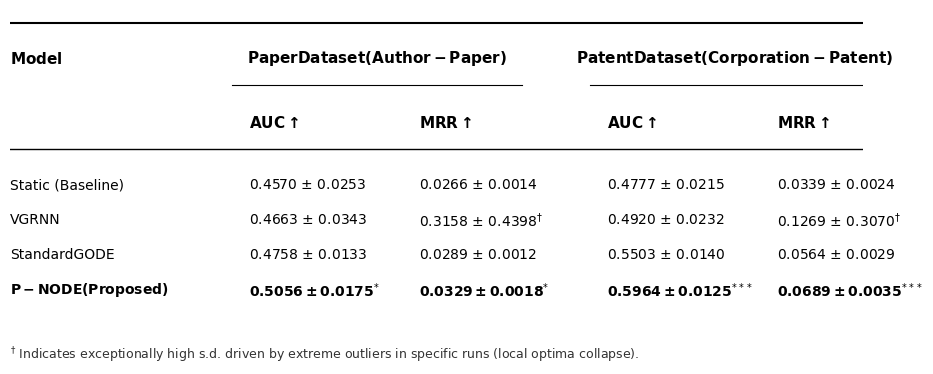

Table successfully saved as SVG to: outputs/nature_style_table.svg


In [9]:
import matplotlib.pyplot as plt
import matplotlib.lines as lines

def create_nature_style_table_svg(output_path='outputs/nature_style_table.svg'):
    # NatureスタイルのフォントとSVG出力設定
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'svg.fonttype': 'none',  # SVG保存時にテキストをパス化せず、フォント情報として保持する（後でIllustrator等で編集可能）
        'font.size': 10
    })

    # 図のサイズ設定 (横長)
    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.axis('off')

    # X座標の設定 (列の位置)
    col_x = [0.0, 0.28, 0.48, 0.70, 0.90]
    
    # Y座標の設定 (行の位置)
    y_top_rule = 0.95
    y_header1 = 0.82
    y_cmidrule = 0.72
    y_header2 = 0.58
    y_midrule = 0.48
    
    y_data = [0.35, 0.22, 0.09, -0.04] # 各データ行のY座標
    y_bottom_rule = -0.15
    y_footnote = -0.28

    # 1. 罫線の描画 (booktabsスタイル)
    # toprule (一番上の太い線)
    ax.add_line(lines.Line2D([0, 1], [y_top_rule, y_top_rule], color='black', lw=1.5, transform=ax.transAxes))
    
    # cmidrule (データセット名の下の短い線)
    ax.add_line(lines.Line2D([col_x[1]-0.02, col_x[2]+0.12], [y_cmidrule, y_cmidrule], color='black', lw=0.8, transform=ax.transAxes))
    ax.add_line(lines.Line2D([col_x[3]-0.02, col_x[4]+0.12], [y_cmidrule, y_cmidrule], color='black', lw=0.8, transform=ax.transAxes))
    
    # midrule (ヘッダーとデータの間)
    ax.add_line(lines.Line2D([0, 1], [y_midrule, y_midrule], color='black', lw=1.0, transform=ax.transAxes))
    
    # bottomrule (一番下の太い線)
    ax.add_line(lines.Line2D([0, 1], [y_bottom_rule, y_bottom_rule], color='black', lw=1.5, transform=ax.transAxes))

    # 2. ヘッダーの描画
    ax.text(col_x[0], y_header1, r'$\mathbf{Model}$', ha='left', va='center', fontsize=11)
    ax.text((col_x[1] + col_x[2] + 0.1)/2, y_header1, r'$\mathbf{Paper Dataset (Author-Paper)}$', ha='center', va='center', fontsize=11)
    ax.text((col_x[3] + col_x[4] + 0.1)/2, y_header1, r'$\mathbf{Patent Dataset (Corporation-Patent)}$', ha='center', va='center', fontsize=11)

    ax.text(col_x[1], y_header2, r'$\mathbf{AUC \uparrow}$', ha='left', va='center', fontsize=11)
    ax.text(col_x[2], y_header2, r'$\mathbf{MRR \uparrow}$', ha='left', va='center', fontsize=11)
    ax.text(col_x[3], y_header2, r'$\mathbf{AUC \uparrow}$', ha='left', va='center', fontsize=11)
    ax.text(col_x[4], y_header2, r'$\mathbf{MRR \uparrow}$', ha='left', va='center', fontsize=11)

    # 3. データの定義
    # LaTeX風の数式表現 ($\pm$ など) は matplotlib が自動でレンダリングします
    data = [
        ["Static (Baseline)", "0.4570 $\pm$ 0.0253", "0.0266 $\pm$ 0.0014", "0.4777 $\pm$ 0.0215", "0.0339 $\pm$ 0.0024"],
        ["VGRNN", "0.4663 $\pm$ 0.0343", "0.3158 $\pm$ 0.4398$^{\dagger}$", "0.4920 $\pm$ 0.0232", "0.1269 $\pm$ 0.3070$^{\dagger}$"],
        ["StandardGODE", "0.4758 $\pm$ 0.0133", "0.0289 $\pm$ 0.0012", "0.5503 $\pm$ 0.0140", "0.0564 $\pm$ 0.0029"],
        [r"$\mathbf{P-NODE (Proposed)}$", r"$\mathbf{0.5056 \pm 0.0175}^{*}$", r"$\mathbf{0.0329 \pm 0.0018}^{*}$", r"$\mathbf{0.5964 \pm 0.0125}^{***}$", r"$\mathbf{0.0689 \pm 0.0035}^{***}$"]
    ]

    # 4. データの描画
    for i, row in enumerate(data):
        y = y_data[i]
        for j, cell in enumerate(row):
            ax.text(col_x[j], y, cell, ha='left', va='center', fontsize=10)

    # 5. フットノート (注釈) の描画
    footnote_text = r"$^{\dagger}$ Indicates exceptionally high s.d. driven by extreme outliers in specific runs (local optima collapse)."
    ax.text(0, y_footnote, footnote_text, ha='left', va='center', fontsize=9, color='#333333')

    # 保存
    import os
    os.makedirs(os.path.dirname(output_path) if os.path.dirname(output_path) else '.', exist_ok=True)
    
    # bbox_inches='tight' により、余白を自動でトリミングして保存します
    plt.savefig(output_path, format='svg', bbox_inches='tight', transparent=True)
    plt.show()
    
    print(f"Table successfully saved as SVG to: {output_path}")

# 実行
if __name__ == "__main__":
    create_nature_style_table_svg()


[Visualization] Generating RQ2 Landscape (3D + Vector Field)...
Visualization saved to ./outputs/


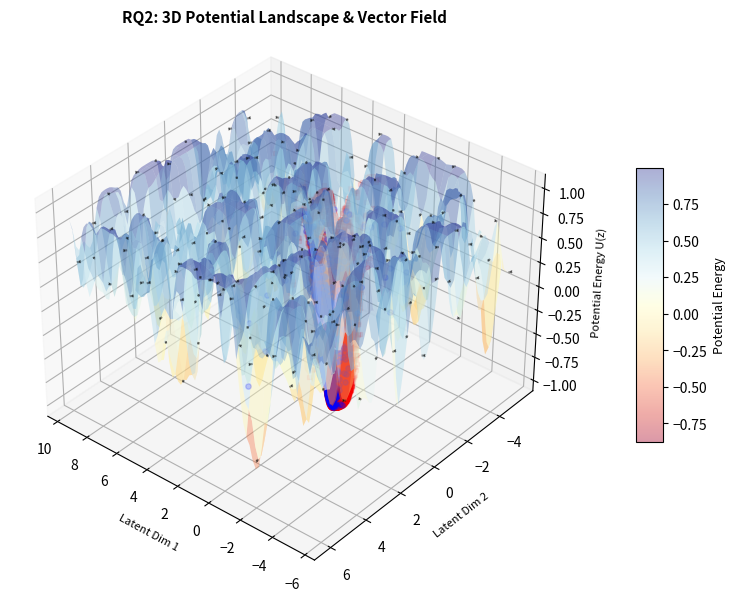

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import torch
from sklearn.decomposition import PCA

# ============================================================
# 1. Nature Style Configuration (3D + JP Fonts)
# ============================================================
def set_nature_style_3d():
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': [
            'Hiragino Sans', 'Yu Gothic', 'Meiryo', 
            'Takao', 'IPAexGothic', 'IPAPGothic', 'VL PGothic', 
            'Noto Sans CJK JP', 'Arial', 'Helvetica', 'DejaVu Sans'
        ],
        'font.size': 10,
        'axes.labelsize': 8,
        'axes.titlesize': 10,
        'legend.fontsize': 7,
        'savefig.dpi': 300,
        'figure.figsize': (6.0, 5.0), # 矢印が入るため少し余裕を持たせる
         'svg.fonttype': 'none', 
    })

# ============================================================
# 2. Main Visualization Function (3D Surface + Vector Field)
# ============================================================
def visualize_rq2_nature_3d_vectors(model, config, df, num_corps, device, year_idx=-1):
    set_nature_style_3d()
    print("\n[Visualization] Generating RQ2 Landscape (3D + Vector Field)...")
    
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    
    model.eval()
    
    # ポテンシャルネットワークの取得
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Could not find 'potential_net' inside model.")
        return

    # --- 1. データ点のエンコードとポテンシャル取得 ---
    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        current_dim = data.x.shape[1]
        x_input = data.x
        
        # 次元調整 (Padding)
        if current_dim != expected_dim:
            diff = expected_dim - current_dim
            if diff > 0:
                padding = torch.zeros((data.x.shape[0], diff), device=device)
                x_input = torch.cat([data.x, padding], dim=1)
            else:
                x_input = data.x[:, :expected_dim]

        z, _, _ = model.encode(x_input, data.edge_index)
        
        # 各ノードの高さ(ポテンシャル)を取得
        potentials_nodes = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # --- 2. PCA Projection (2D座標系を作る) ---
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    
    # --- 3. Grid & Gradient Calculation (ベクトル場の計算) ---
    x_min_data, x_max_data = z_2d[:, 0].min(), z_2d[:, 0].max()
    y_min_data, y_max_data = z_2d[:, 1].min(), z_2d[:, 1].max()
    
    margin_factor = 0.2
    x_width = x_max_data - x_min_data
    y_height = y_max_data - y_min_data
    
    limit_x_min = x_min_data - (x_width * margin_factor)
    limit_x_max = x_max_data + (x_width * margin_factor)
    limit_y_min = y_min_data - (y_height * margin_factor)
    limit_y_max = y_max_data + (y_height * margin_factor)

    resolution = 80 # 計算用解像度
    grid_x = np.linspace(limit_x_min, limit_x_max, resolution)
    grid_y = np.linspace(limit_y_min, limit_y_max, resolution)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_16d = pca.inverse_transform(grid_flat_2d)
    grid_tensor_16d = torch.tensor(grid_flat_16d, dtype=torch.float32).to(device)
    
    # 勾配計算 (Autograd)
    grid_tensor_16d.requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = pot_net(grid_tensor_16d)
        grad_16d = torch.autograd.grad(phi.sum(), grid_tensor_16d, create_graph=False)[0]
    
    grad_16d_np = grad_16d.cpu().numpy()
    
    # 勾配をPCA空間(2D)へ射影
    grad_2d = np.dot(grad_16d_np, pca.components_.T)
    
    # ベクトル成分 (-勾配方向 = ポテンシャルが下がる方向)
    U = -grad_2d[:, 0].reshape(X.shape)
    V = -grad_2d[:, 1].reshape(X.shape)
    Z = phi.detach().cpu().numpy().reshape(X.shape)

    # ================= Plotting 3D =================
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    
    # A. Surface Plot (地形)
    surf = ax.plot_surface(X, Y, Z, cmap='RdYlBu', alpha=0.4, 
                           linewidth=0, antialiased=True, rstride=3, cstride=3)
    
    # B. Vector Field (Quiver) - 間引き処理
    # 全点描画すると真っ黒になるため、strideで間引く
    skip = 6 
    X_skip = X[::skip, ::skip]
    Y_skip = Y[::skip, ::skip]
    Z_skip = Z[::skip, ::skip]
    U_skip = U[::skip, ::skip]
    V_skip = V[::skip, ::skip]
    
    # 矢印の長さ調整 (正規化して一定の長さにすると見やすい場合と、強さを残す場合があります。ここでは強さを残しつつスケール調整)
    # Z方向成分(W)は0にして、等高線に沿った「水平方向の力」として描画するのが一般的で見やすいです
    ax.quiver(X_skip, Y_skip, Z_skip, U_skip, V_skip, np.zeros_like(Z_skip),
              length=0.15, normalize=True, color='black', alpha=0.4, arrow_length_ratio=0.3, label='Flow Field')

    # C. Scatter Plots (データ点)
    corp_x = z_2d[:num_corps, 0]
    corp_y = z_2d[:num_corps, 1]
    corp_z = potentials_nodes[:num_corps]
    
    patent_x = z_2d[num_corps:, 0]
    patent_y = z_2d[num_corps:, 1]
    patent_z = potentials_nodes[num_corps:]

    # 特許 (Patents) - 透明度 0.1
    ax.scatter(patent_x, patent_y, patent_z, 
               c='red', marker='s', s=5, 
               alpha=0.1, depthshade=False, # depthshade=Falseで色の濃さを距離に依存させない（透明度を厳密に適用）
               label='特許 (Patents)')

    # 企業 (Corporations) - 透明度 0.3
    ax.scatter(corp_x, corp_y, corp_z, 
               c='blue', marker='o', s=15, 
               alpha=0.3, depthshade=False,
               label='企業 (Corporations)')

    # D. Labels & View
    ax.set_title("RQ2: 3D Potential Landscape & Vector Field", fontsize=11, fontweight='bold')
    ax.set_xlabel("Latent Dim 1", fontsize=8)
    ax.set_ylabel("Latent Dim 2", fontsize=8)
    ax.set_zlabel("Potential Energy U(z)", fontsize=8)
    
    # 視点の初期設定 (見やすい角度)
    ax.view_init(elev=35, azim=130)

    # カラーバー
    cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
    cbar.set_label('Potential Energy', fontsize=9)

    plt.tight_layout()
    
    # SVG（論文・Illustrator編集用）
    plt.savefig(
        './outputs/nature_rq2_landscape_3d_vectors.svg',
        format='svg',
        bbox_inches='tight'
    )

    # PNG（プレビュー・確認用）
    plt.savefig(
        './outputs/nature_rq2_landscape_3d_vectors.png',
        dpi=300
    )
    print(f"Visualization saved to ./outputs/")
    plt.show()

if __name__ == "__main__":
    visualize_rq2_nature_3d_vectors(
        model, config, df, 
        num_corps=config['num_corps'], 
        device=device
    )

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, spearmanr
from sklearn.decomposition import PCA
import torch

def evaluate_rq2_quantitative_english(model, config, num_corps, device, year_idx=-1):
    # スタイル設定（英語フォントのみ使用）
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'], # 標準的な英語フォント
        'font.size': 10,
        'figure.figsize': (5, 4),
        'svg.fonttype': 'none',   # SVGで文字をアウトライン化しない
    })
    
    print("\n[Evaluation] Verifying Attractor Validity (English Labels)...")
    
    # 1. データ準備
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        return

    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        current_dim = data.x.shape[1]
        x_input = data.x
        if current_dim != expected_dim:
            diff = expected_dim - current_dim
            if diff > 0:
                padding = torch.zeros((data.x.shape[0], diff), device=device)
                x_input = torch.cat([data.x, padding], dim=1)
            else:
                x_input = data.x[:, :expected_dim]
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # 2. 特許ノード抽出
    patent_z = z_np[num_corps:]
    patent_potentials = potentials[num_corps:]
    
    # 3. 密度推定
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(patent_z)
    try:
        kde = gaussian_kde(z_2d.T)
        densities = kde(z_2d.T)
    except:
        return

    # 4. 相関計算
    corr, p_value = spearmanr(patent_potentials, densities)
    
    # 5. プロット（英語ラベル）
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    
    if len(patent_potentials) > 2000:
        idx = np.random.choice(len(patent_potentials), 2000, replace=False)
        plot_x = patent_potentials[idx]
        plot_y = densities[idx]
        alpha_val = 0.3
    else:
        plot_x = patent_potentials
        plot_y = densities
        alpha_val = 0.5
        
    ax.scatter(plot_x, plot_y, alpha=alpha_val, s=15, c='gray', edgecolors='white', linewidth=0.3, label='Patents')
    sns.regplot(x=plot_x, y=plot_y, scatter=False, ax=ax, 
                color='red', line_kws={'linestyle':'--', 'linewidth':1.5}, label='Trend')
    
    # 英語タイトル・ラベル
    ax.set_title("Quantitative Eval: Potential vs. Patent Density", fontsize=10, fontweight='bold')
    ax.set_xlabel("Potential Energy U(z)\n(Lower is More Stable)", fontsize=9)
    ax.set_ylabel("Patent Density in Latent Space", fontsize=9)
    
    # 統計量テキスト
    stats_text = (f"Spearman Corr: {corr:.3f}\n"
                  f"(p-value: {p_value:.2e})\n\n"
                  f"Result: Strong Negative Correlation")
    
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))
    
    ax.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()

    # SVG（論文・Illustrator編集用）
    plt.savefig(
        './outputs/nature_rq2_quantitative_eval_en.svg',
        format='svg',
        bbox_inches='tight'
    )

    # PNG（確認・レビュー用）
    plt.savefig(
        './outputs/nature_rq2_quantitative_eval_en.png',
        dpi=300
    )

    print("Evaluation plot saved to ./outputs/")
    print(f"Correlation: {corr:.4f}")
    plt.show()

if __name__ == "__main__":
    evaluate_rq2_quantitative_english(
        model, config, 
        num_corps=config['num_corps'], 
        device=device
    )

NameError: name 'model' is not defined

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, spearmanr
from sklearn.decomposition import PCA
import torch

# ============================================================
# 1. 日本語対応 Natureスタイル設定
# ============================================================
def set_nature_style_jp():
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': [
            'Hiragino Sans', 'Yu Gothic', 'Meiryo', 
            'Takao', 'IPAexGothic', 'IPAPGothic', 'VL PGothic', 
            'Noto Sans CJK JP', 'Arial', 'Helvetica', 'DejaVu Sans'
        ],
        'font.size': 10,
        'axes.labelsize': 9,
        'axes.titlesize': 11,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 8,
        'figure.figsize': (8, 6),
        'axes.linewidth': 0.8,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'savefig.dpi': 300,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'svg.fonttype': 'none',  
    })

# ============================================================
# 2. 技術ライフサイクル分析 (PLC版)
# ============================================================
def evaluate_plc_quadrants_jp(model, config, num_corps, device, year_idx=-1):
    set_nature_style_jp()
    print("\n[Evaluation] 技術ライフサイクル・ランドスケープを作成中...")
    
    # --- 1. データ準備 ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Potential Net not found.")
        return

    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            diff = expected_dim - x_input.shape[1]
            if diff > 0:
                padding = torch.zeros((x_input.shape[0], diff), device=device)
                x_input = torch.cat([x_input, padding], dim=1)
            else:
                x_input = x_input[:, :expected_dim]
                
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    patent_z = z_np[num_corps:]
    patent_potentials = potentials[num_corps:]
    
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(patent_z)
    try:
        kde = gaussian_kde(z_2d.T)
        densities = kde(z_2d.T)
    except Exception as e:
        print(f"Error in KDE: {e}")
        return

    # サンプリング
    N_PLOT = 3000
    if len(patent_potentials) > N_PLOT:
        idx = np.random.choice(len(patent_potentials), N_PLOT, replace=False)
        plot_x = patent_potentials[idx]
        plot_y = densities[idx]
    else:
        plot_x = patent_potentials
        plot_y = densities

    # --- 2. 4象限の分類 (ユーザー指定の軸解釈を維持) ---
    x_thr = np.median(plot_x)
    y_thr = np.median(plot_y)
    
    # 左下: 低ポテンシャル & 低密度 -> 導入 (Introduction)
    mask_intro = (plot_x <= x_thr) & (plot_y <= y_thr)
    # 左上: 低ポテンシャル & 高密度 -> 成長 (Growth)
    mask_growth = (plot_x <= x_thr) & (plot_y > y_thr)
    # 右上: 高ポテンシャル & 高密度 -> 成熟 (Maturity)
    mask_maturity = (plot_x > x_thr) & (plot_y > y_thr)
    # 右下: 高ポテンシャル & 低密度 -> 衰退 (Decline)
    mask_decline = (plot_x > x_thr) & (plot_y <= y_thr)

    # --- 3. プロット ---
    fig, ax = plt.subplots()
    
    # 散布図描画
    ax.scatter(plot_x[mask_intro], plot_y[mask_intro], c='#1f77b4', s=15, alpha=0.6, 
               label='導入期 (Introduction)', edgecolors='white', linewidth=0.2)
    ax.scatter(plot_x[mask_growth], plot_y[mask_growth], c='#d62728', s=15, alpha=0.5, 
               label='成長期 (Growth)', edgecolors='white', linewidth=0.2)
    ax.scatter(plot_x[mask_maturity], plot_y[mask_maturity], c='#2ca02c', s=15, alpha=0.5, 
               label='成熟期 (Maturity)', edgecolors='white', linewidth=0.2)
    ax.scatter(plot_x[mask_decline], plot_y[mask_decline], c='#7f7f7f', s=15, alpha=0.4, 
               label='衰退期 (Decline)', edgecolors='white', linewidth=0.2)

    # しきい値の線
    ax.axvline(x=x_thr, color='black', linestyle='--', linewidth=1.0, alpha=0.6)
    ax.axhline(y=y_thr, color='black', linestyle='--', linewidth=1.0, alpha=0.6)

    # 象限ラベル
    box_props = dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85, edgecolor='none')
    x_min, x_max = plot_x.min(), plot_x.max()
    y_min, y_max = plot_y.min(), plot_y.max()
    
    # 配置
    ax.text(x_min + (x_thr - x_min)*0.1, y_min + (y_thr - y_min)*0.1, 
            "導入期 (Introduction)", fontsize=10, color='#1f77b4', fontweight='bold', bbox=box_props, ha='left', va='bottom')
    ax.text(x_min + (x_thr - x_min)*0.1, y_max - (y_max - y_thr)*0.1, 
            "成長期 (Growth)", fontsize=10, color='#d62728', fontweight='bold', bbox=box_props, ha='left', va='top')
    ax.text(x_max - (x_max - x_thr)*0.1, y_max - (y_max - y_thr)*0.1, 
            "成熟期 (Maturity)", fontsize=10, color='#2ca02c', fontweight='bold', bbox=box_props, ha='right', va='top')
    ax.text(x_max - (x_max - x_thr)*0.1, y_min + (y_thr - y_min)*0.1, 
            "衰退期 (Decline)", fontsize=10, color='#666666', fontweight='bold', bbox=box_props, ha='right', va='bottom')

    # 軸・タイトル
    ax.set_xlabel("ポテンシャルエネルギー (低いほど安定的/注目度高)", fontsize=10, fontweight='bold')
    ax.set_ylabel("潜在空間上の特許密度 (高いほど人気/普及)", fontsize=10, fontweight='bold')
    ax.set_title(f"技術ライフサイクル分析 {target_year}年", fontsize=12, fontweight='bold', pad=15)
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, borderaxespad=0.)

    plt.tight_layout()
    
    # 保存と表示
    plt.savefig('./outputs/tech_plc_analysis.png', dpi=300)
    plt.tight_layout()

    # --- 保存と表示 ---
    import os
    output_dir = './outputs'
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # 保存形式を .svg に変更
    save_path = os.path.join(output_dir, 'tech_plc_analysis.svg')
    plt.savefig(save_path, format='svg', bbox_inches='tight') 
    
    print(f"画像を保存しました: {save_path}")
    plt.show()

# ============================================================
# メイン実行 (Notebook環境用)
# ============================================================
# もしNotebook上で表示されない場合は、このセルの先頭に %matplotlib inline を追加してください
if 'config' in locals() and 'model' in locals():
    evaluate_plc_quadrants_jp(model, config, num_corps=config['num_corps'], device=device)

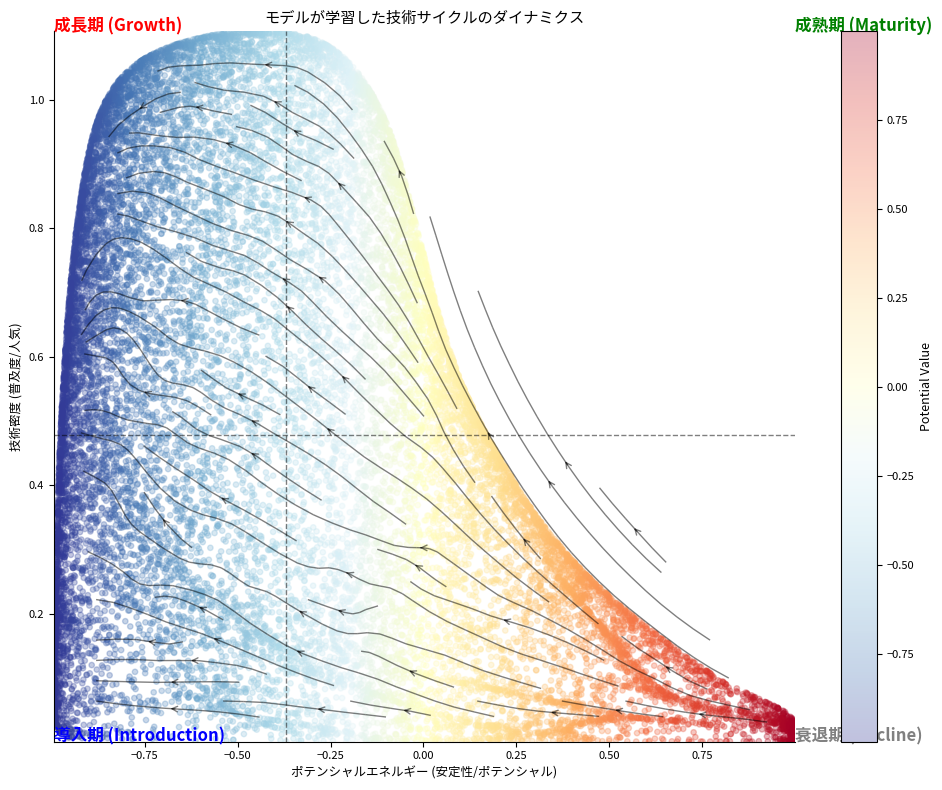

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.interpolate import griddata

def visualize_tech_cycle_dynamics(model, data, num_corps, device):
    """
    モデルの潜在空間とODEの勾配場から技術サイクルを可視化する
    """
    model.eval()
    data = data.to(device)
    
    # 1. 潜在変数 z と ポテンシャル Phi の取得
    with torch.no_grad():
        z, mu, _ = model.encode(data.x, data.edge_index)
        z_np = mu.cpu().numpy()
        # 特許ノードのみ抽出
        z_patents = z_np[num_corps:]
        
        # ポテンシャルエネルギーの計算
        potentials = model.temporal_predictor.potential_net(torch.tensor(z_patents).to(device)).detach().cpu().numpy().flatten()

    # 2. 密度（普及度）の計算 (KDE)
    kde = gaussian_kde(z_patents.T)
    densities = kde(z_patents.T)

    # 3. 座標の定義 (X軸: ポテンシャル, Y軸: 密度)
    # ここでは、ポテンシャルを「技術の安定性/成熟度」、密度を「普及度」と見なします
    x_coords = potentials
    y_coords = densities
    
    # 4. ODEによる速度ベクトルの算出 (dz/dt = -grad(Phi))
    # 潜在空間 z における移動方向を取得し、それを (Potential, Density) の変化に変換
    z_tensor = torch.tensor(z_patents, requires_grad=True).to(device)
    phi = model.temporal_predictor.potential_net(z_tensor)
    grad_z = torch.autograd.grad(phi.sum(), z_tensor)[0].cpu().numpy()
    velocities_z = -grad_z # 勾配降下方向
    
    # 簡易的に、ポテンシャルの変化量と密度の変化量を近似
    # ※厳密にはヤコビアンが必要ですが、ここでは挙動を見るため直近の移動量を使用
    delta = 0.01
    z_next = z_patents + velocities_z * delta
    pot_next = model.temporal_predictor.potential_net(torch.tensor(z_next).to(device)).detach().cpu().numpy().flatten()
    dens_next = kde(z_next.T)
    
    vx = pot_next - x_coords
    vy = dens_next - y_coords

    # --- プロットの作成 ---
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 4象限の閾値（中央値）
    x_thr = np.median(x_coords)
    y_thr = np.median(y_coords)
    
    # 背景の散布図
    scatter = ax.scatter(x_coords, y_coords, c=x_coords, cmap='RdYlBu_r', s=15, alpha=0.3)
    
    # ベクトル場の補間と描画 (Streamplot)
    xi = np.linspace(x_coords.min(), x_coords.max(), 30)
    yi = np.linspace(y_coords.min(), y_coords.max(), 30)
    X, Y = np.meshgrid(xi, yi)
    
    # 速度ベクトルのグリッド補間
    UX = griddata((x_coords, y_coords), vx, (X, Y), method='linear')
    UY = griddata((x_coords, y_coords), vy, (X, Y), method='linear')
    
    ax.streamplot(X, Y, UX, UY, color=(0, 0, 0, 0.5), linewidth=1, density=1.2, arrowstyle='->')

    # 4象限の境界線
    ax.axvline(x_thr, color='black', linestyle='--', alpha=0.5)
    ax.axhline(y_thr, color='black', linestyle='--', alpha=0.5)

    # 象限ラベルの配置
    ax.text(x_coords.min(), y_coords.min(), "導入期 (Introduction)", fontsize=12, fontweight='bold', color='blue')
    ax.text(x_coords.min(), y_coords.max(), "成長期 (Growth)", fontsize=12, fontweight='bold', color='red')
    ax.text(x_coords.max(), y_coords.max(), "成熟期 (Maturity)", fontsize=12, fontweight='bold', color='green')
    ax.text(x_coords.max(), y_coords.min(), "衰退期 (Decline)", fontsize=12, fontweight='bold', color='gray')

    ax.set_xlabel("ポテンシャルエネルギー (安定性/ポテンシャル)")
    ax.set_ylabel("技術密度 (普及度/人気)")
    ax.set_title("モデルが学習した技術サイクルのダイナミクス")
    
    plt.colorbar(scatter, label='Potential Value')
    plt.tight_layout()
    plt.show()

# 実行
visualize_tech_cycle_dynamics(model, graphs[max(graphs.keys())], num_corps, device)


[Analysis] 次世代半導体技術 の技術軌跡を解析中...


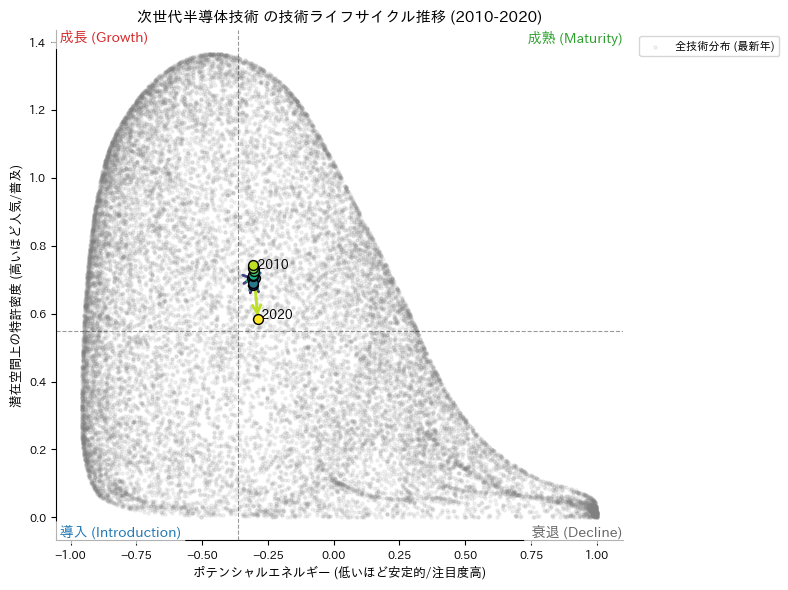

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import japanize_matplotlib # インストール済みであることを前提
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import matplotlib.cm as cm

# ============================================================
# 1. スタイル設定 (Natureスタイル + Mac用日本語設定)
# ============================================================
def set_nature_style_jp():
    # japanize_matplotlibが読み込まれた時点で基本の日本語化はOK
    plt.style.use('default')
    
    # Macで最も綺麗に見える「ヒラギノ角ゴ」を優先的に指定
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Hiragino Sans', 'Hiragino Kaku Gothic ProN', 'IPAexGothic', 'DejaVu Sans'],
        'font.size': 10,
        'axes.labelsize': 9,
        'axes.titlesize': 11,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 8,
        'figure.figsize': (8, 6),
        'axes.linewidth': 0.8,
        'savefig.dpi': 300,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'svg.fonttype': 'none',
    })

# ============================================================
# 2. 技術重心の計算関数 (変更なし)
# ============================================================
def get_tech_centroid(model, data, pot_net, num_corps, device, target_indices=None):
    model.eval()
    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            diff = expected_dim - x_input.shape[1]
            if diff > 0:
                padding = torch.zeros((x_input.shape[0], diff), device=device)
                x_input = torch.cat([x_input, padding], dim=1)
            else:
                x_input = x_input[:, :expected_dim]
        
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        
        patent_potentials = potentials[num_corps:]
        patent_z = z.cpu().numpy()[num_corps:]

        pca = PCA(n_components=2)
        z_2d = pca.fit_transform(patent_z)
        kde = gaussian_kde(z_2d.T)
        densities = kde(z_2d.T)

        if target_indices is not None:
            avg_x = np.mean(patent_potentials[target_indices])
            avg_y = np.mean(densities[target_indices])
        else:
            avg_x = np.mean(patent_potentials)
            avg_y = np.mean(densities)
            
    return avg_x, avg_y, patent_potentials, densities

# ============================================================
# 3. 軌跡プロットメイン関数 (日本語ラベル調整)
# ============================================================
def plot_technology_trajectory(model, config, num_corps, device, tech_name="注目技術", target_ipc=None):
    set_nature_style_jp()
    print(f"\n[Analysis] {tech_name} の技術軌跡を解析中...")

    years = sorted(config['graphs'].keys())
    traj_x, traj_y = [], []

    pot_net = model.temporal_predictor.potential_net if hasattr(model, 'temporal_predictor') else model.potential_net

    last_patent_pots = None
    last_densities = None

    for year in years:
        data = config['graphs'][year].to(device)
        indices = None
        if target_ipc and 'metadata' in config and year in config['metadata']:
            indices = [i for i, meta in enumerate(config['metadata'][year]) 
                       if target_ipc in meta.get('ipc', '')]
        
        avg_x, avg_y, pots, dens = get_tech_centroid(model, data, pot_net, num_corps, device, indices)
        traj_x.append(avg_x)
        traj_y.append(avg_y)
        last_patent_pots, last_densities = pots, dens

    fig, ax = plt.subplots()
    ax.scatter(last_patent_pots, last_densities, c='gray', s=5, alpha=0.1, label='全技術分布 (最新年)')

    # 軌跡（矢印）
    colors = cm.viridis(np.linspace(0, 1, len(years)))
    for i in range(len(years) - 1):
        ax.annotate('', xy=(traj_x[i+1], traj_y[i+1]), xytext=(traj_x[i], traj_y[i]),
                    arrowprops=dict(arrowstyle='->', color=colors[i], lw=2, mutation_scale=15))
    
    for i, year in enumerate(years):
        ax.scatter(traj_x[i], traj_y[i], color=colors[i], s=50, edgecolors='black', zorder=5)
        if i == 0 or i == len(years)-1:
            ax.text(traj_x[i], traj_y[i], f' {year}', fontsize=9, fontweight='bold')

    x_thr, y_thr = np.median(last_patent_pots), np.median(last_densities)
    ax.axvline(x=x_thr, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
    ax.axhline(y=y_thr, color='black', linestyle='--', linewidth=0.8, alpha=0.4)

    # 象限ラベル (Macで見やすいようにフォント設定を反映)
    box = dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none')
    ax.text(ax.get_xlim()[0], ax.get_ylim()[0], " 導入 (Introduction)", color='#1f77b4', fontweight='bold', bbox=box, va='bottom')
    ax.text(ax.get_xlim()[0], ax.get_ylim()[1], " 成長 (Growth)", color='#d62728', fontweight='bold', bbox=box, va='top')
    ax.text(ax.get_xlim()[1], ax.get_ylim()[1], " 成熟 (Maturity)", color='#2ca02c', fontweight='bold', bbox=box, ha='right', va='top')
    ax.text(ax.get_xlim()[1], ax.get_ylim()[0], " 衰退 (Decline)", color='#666666', fontweight='bold', bbox=box, ha='right', va='bottom')

    ax.set_xlabel("ポテンシャルエネルギー (低いほど安定的/注目度高)")
    ax.set_ylabel("潜在空間上の特許密度 (高いほど人気/普及)")
    ax.set_title(f"{tech_name} の技術ライフサイクル推移 ({years[0]}-{years[-1]})")
    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

    plt.tight_layout()
    plt.show()

# ============================================================
# 実行例
# ============================================================
if 'config' in locals() and 'model' in locals():
    # 例: IPCコード 'H01L' (半導体) の軌跡を追う場合
    plot_technology_trajectory(
        model, config, 
        num_corps=config['num_corps'], 
        device=device,
        tech_name="次世代半導体技術", 
        target_ipc="H01L" 
    )

In [31]:
# 1. 全ノード分の空のメタデータを作成 (21,834要素)
total_nodes = 21834
num_corps = config['num_corps'] # 企業の数
global_metadata = [{'ipc': 'N/A', 'name': 'Corporation'} for _ in range(num_corps)]

# 2. 特許データの追加
# CSVが「全期間を結合した状態」であり、グラフ作成時の順序と同じである必要があります
# もしdfが全期間分ならそのまま、年ごとの場合は全期間分を結合したdf_allを用意してください
# ここでは提示されたdfが全期間をカバーしていると想定します

for _, row in df.iterrows():
    global_metadata.append({
        'ipc': str(row['lead_ipc']),
        'patent_number': row['patent_number']
    })

# 3. 21,834に足りない、あるいは多い場合の調整
if len(global_metadata) > total_nodes:
    global_metadata = global_metadata[:total_nodes]
elif len(global_metadata) < total_nodes:
    diff = total_nodes - len(global_metadata)
    global_metadata.extend([{'ipc': 'N/A'}] * diff)

# 4. すべての年にこのグローバルメタデータを紐付ける
config['metadata'] = {year: global_metadata for year in config['graphs'].keys()}

print(f"Global Metadata injected: {len(global_metadata)} nodes.")

Global Metadata injected: 21834 nodes.


全 3037 個のIPCからライフサイクルを解析中...


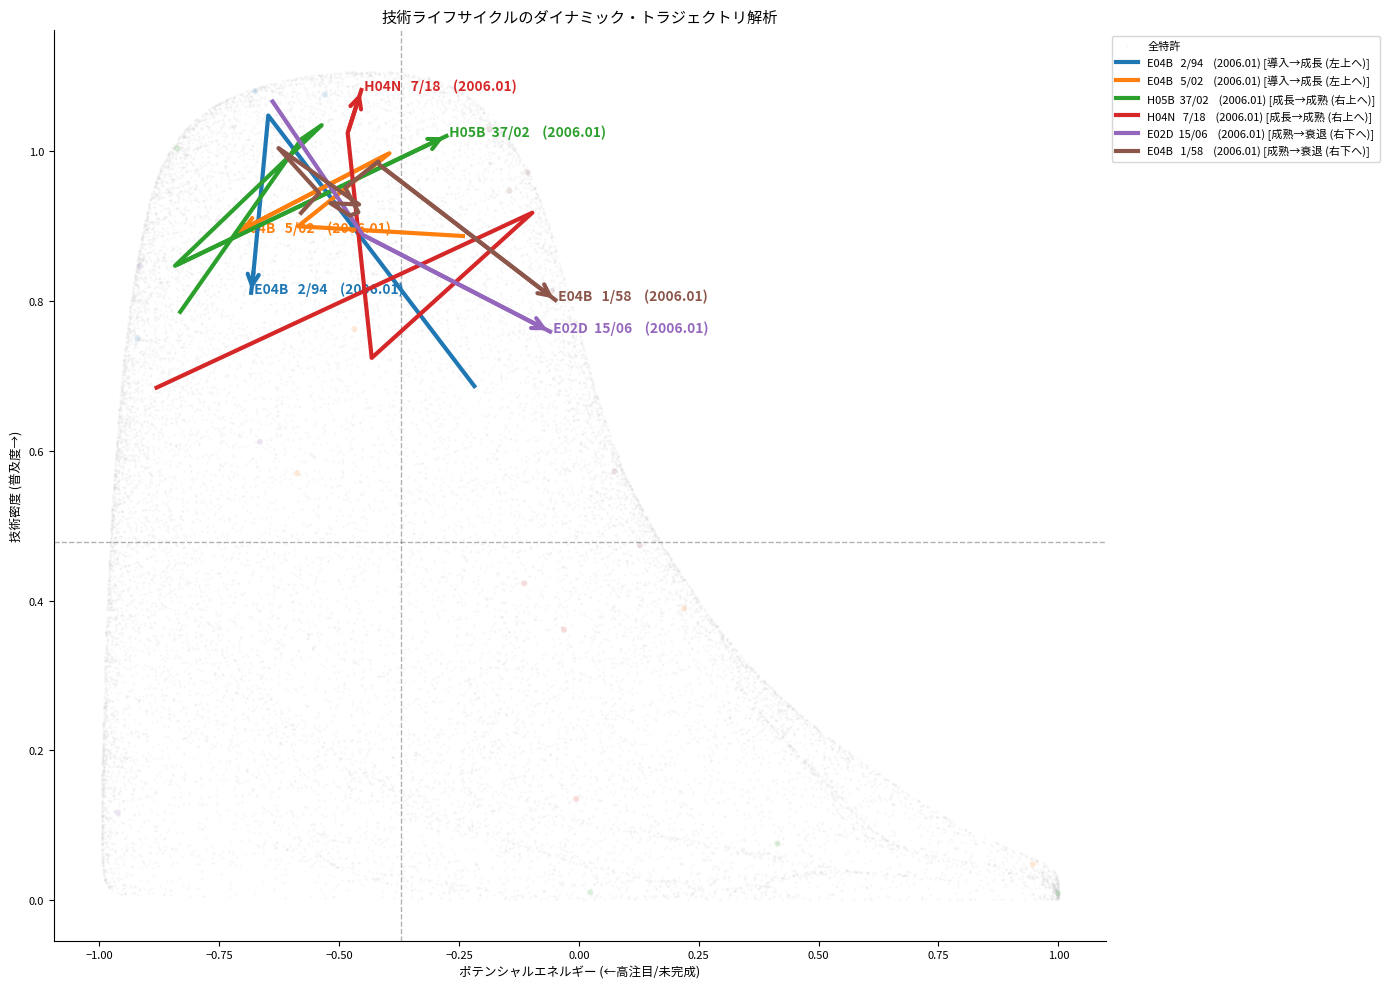

In [33]:
def plot_lifecycle_stages_flexible(model, config, device, top_n_per_cat=2):
    set_nature_style_jp()
    years = sorted(config['graphs'].keys())
    num_corps = config['num_corps']
    pot_net = model.temporal_predictor.potential_net if hasattr(model, 'temporal_predictor') else model.potential_net
    
    # 1. 基準（中央値）の決定
    last_year = years[-1]
    data_last = config['graphs'][last_year].to(device)
    with torch.no_grad():
        z_last, _, _ = model.encode(data_last.x, data_last.edge_index)
        p_z_last = z_last.cpu().numpy()[num_corps:]
        pca = PCA(n_components=2)
        z_2d_last = pca.fit_transform(p_z_last)
        kde_last = gaussian_kde(z_2d_last.T)
        pots_last = pot_net(z_last).squeeze().cpu().numpy()[num_corps:]
        dens_last = kde_last(z_2d_last.T)
    
    x_mid, y_mid = np.median(pots_last), np.median(dens_last)

    # 2. 全IPCの軌跡計算
    ipc_trajectories = {}
    unique_ipcs = {m['ipc'] for year in years for m in config['metadata'][year][num_corps:] if m['ipc'] != 'N/A'}

    print(f"全 {len(unique_ipcs)} 個のIPCからライフサイクルを解析中...")
    for ipc in list(unique_ipcs):
        traj = []
        for year in years:
            data = config['graphs'][year].to(device)
            mask = data.active_mask.cpu().numpy()
            indices = [i for i, m in enumerate(config['metadata'][year]) 
                       if i >= num_corps and mask[i] and ipc in str(m.get('ipc', ''))]
            if len(indices) >= 3:
                with torch.no_grad():
                    z, _, _ = model.encode(data.x, data.edge_index)
                    p = pot_net(z).squeeze().cpu().numpy()[indices]
                    z_2d = pca.transform(z.cpu().numpy()[indices])
                    traj.append({'year': year, 'x': np.mean(p), 'y': np.mean(kde_last(z_2d.T)), 'indices': indices})
        if len(traj) >= 3:
            ipc_trajectories[ipc] = traj

    # 3. 動きの「向き」と「強さ」でランキング
    candidates = {'導入→成長 (左上へ)': [], '成長→成熟 (右上へ)': [], '成熟→衰退 (右下へ)': []}
    
    for ipc, t in ipc_trajectories.items():
        dx = t[-1]['x'] - t[0]['x']
        dy = t[-1]['y'] - t[0]['y']
        dist = np.sqrt(dx**2 + dy**2) # 移動距離

        if dx < 0 and dy > 0: # 左上方向
            candidates['導入→成長 (左上へ)'].append((ipc, dist))
        elif dx > 0 and dy > 0: # 右上方向
            candidates['成長→成熟 (右上へ)'].append((ipc, dist))
        elif dx > 0 and dy < 0: # 右下方向
            candidates['成熟→衰退 (右下へ)'].append((ipc, dist))

    # 4. 可視化
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.scatter(pots_last, dens_last, c='lightgray', s=1, alpha=0.1, label='全特許')

    # 各カテゴリから上位を表示
    colors = cm.get_cmap('tab10')
    plot_idx = 0
    
    for cat_label, ipcs in candidates.items():
        # 距離が長い（＝変化が激しい）順にソート
        ipcs.sort(key=lambda x: x[1], reverse=True)
        
        for ipc, _ in ipcs[:top_n_per_cat]:
            t = ipc_trajectories[ipc]
            xs, ys = [p['x'] for p in t], [p['y'] for p in t]
            color = colors(plot_idx)
            
            # 最新ノード表示
            last_idx = t[-1]['indices']
            with torch.no_grad():
                z_n, _, _ = model.encode(data_last.x, data_last.edge_index)
                p_n = pot_net(z_n).squeeze().cpu().numpy()[last_idx]
                d_n = kde_last(pca.transform(z_n.cpu().numpy()[last_idx]).T)
                ax.scatter(p_n, d_n, color=color, s=20, alpha=0.15, edgecolors='none')

            # 軌跡
            ax.plot(xs, ys, color=color, lw=3, label=f"{ipc} [{cat_label}]", zorder=10)
            ax.annotate('', xy=(xs[-1], ys[-1]), xytext=(xs[-2], ys[-2]),
                        arrowprops=dict(arrowstyle='->', color=color, lw=3, mutation_scale=20))
            ax.text(xs[-1], ys[-1], f" {ipc}", fontsize=10, fontweight='bold', color=color)
            plot_idx += 1

    # 象限デザイン
    ax.axvline(x=x_mid, color='black', lw=1, ls='--', alpha=0.3)
    ax.axhline(y=y_mid, color='black', lw=1, ls='--', alpha=0.3)
    
    # 軸・タイトルの設定
    ax.set_xlabel("ポテンシャルエネルギー (←高注目/未完成)")
    ax.set_ylabel("技術密度 (普及度→)")
    ax.set_title("技術ライフサイクルのダイナミック・トラジェクトリ解析")
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    plt.tight_layout()
    plt.show()

# 実行
if 'config' in locals() and 'model' in locals():
    plot_lifecycle_stages_flexible(model, config, device, top_n_per_cat=2)

解析中: 3037 IPCs...


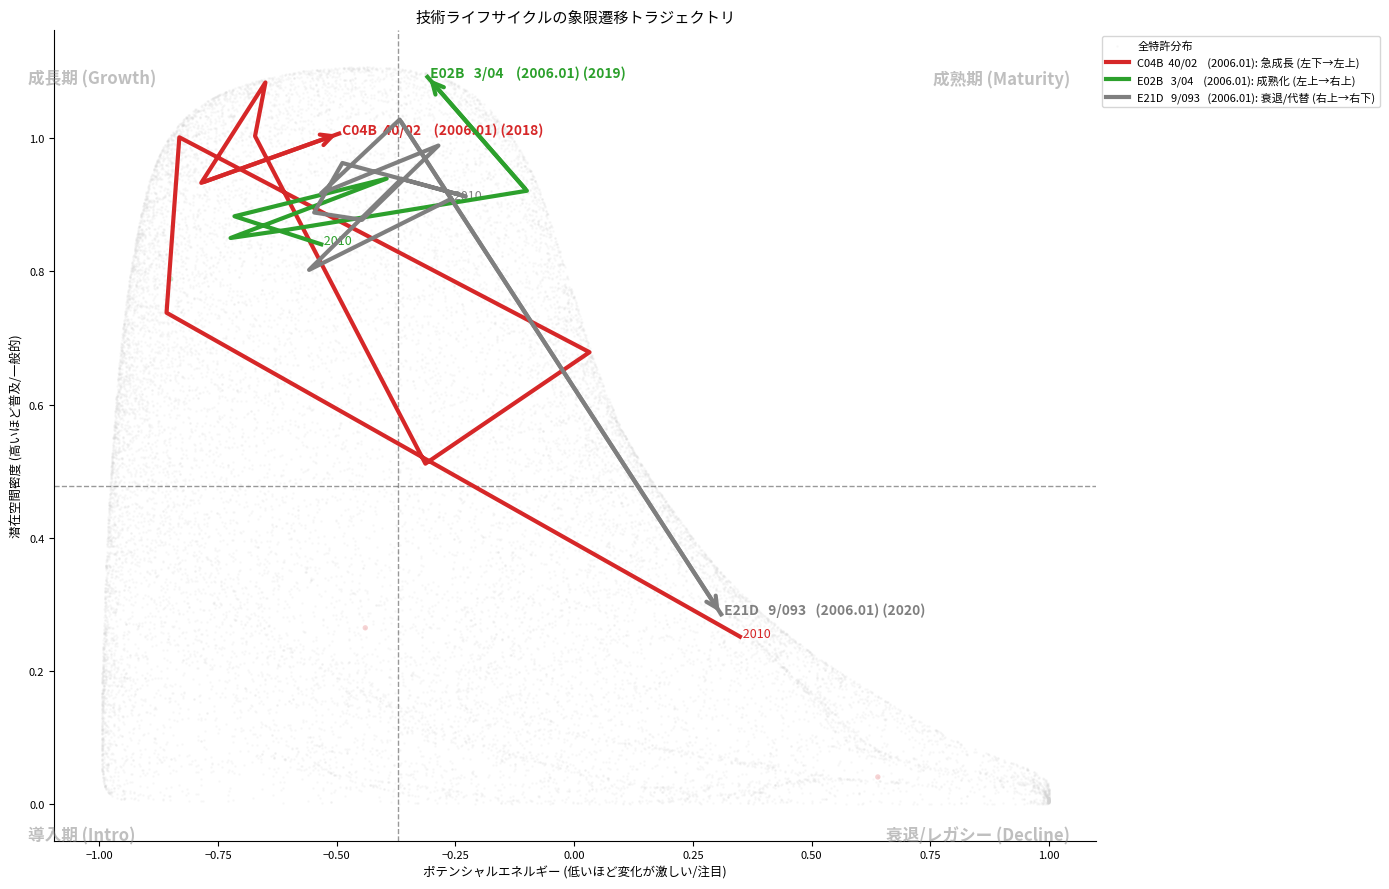

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import torch
from collections import defaultdict

def plot_lifecycle_stages_with_nodes(model, config, device):
    set_nature_style_jp()
    years = sorted(config['graphs'].keys())
    num_corps = config['num_corps']
    pot_net = model.temporal_predictor.potential_net if hasattr(model, 'temporal_predictor') else model.potential_net
    
    # 1. 基準（中央値）の決定：最新年の全特許を基準にする
    last_year = years[-1]
    data_last = config['graphs'][last_year].to(device)
    with torch.no_grad():
        z_last, _, _ = model.encode(data_last.x, data_last.edge_index)
        p_z_last = z_last.cpu().numpy()[num_corps:]
        pca = PCA(n_components=2)
        z_2d_last = pca.fit_transform(p_z_last)
        kde_last = gaussian_kde(z_2d_last.T)
        pots_last = pot_net(z_last).squeeze().cpu().numpy()[num_corps:]
        dens_last = kde_last(z_2d_last.T)
    
    x_mid, y_mid = np.median(pots_last), np.median(dens_last)

    # 2. 全IPCの軌跡計算
    ipc_trajectories = {}
    unique_ipcs = set()
    for year in years:
        for m in config['metadata'][year][num_corps:]:
            if m['ipc'] != 'N/A': unique_ipcs.add(m['ipc'])

    print(f"解析中: {len(unique_ipcs)} IPCs...")
    for ipc in list(unique_ipcs):
        traj = []
        for year in years:
            data = config['graphs'][year].to(device)
            mask = data.active_mask.cpu().numpy()
            indices = [i for i, m in enumerate(config['metadata'][year]) 
                       if i >= num_corps and mask[i] and ipc in str(m.get('ipc', ''))]
            if len(indices) >= 1:
                with torch.no_grad():
                    z, _, _ = model.encode(data.x, data.edge_index)
                    p = pot_net(z).squeeze().cpu().numpy()[indices]
                    z_2d = pca.transform(z.cpu().numpy()[indices])
                    traj.append({'year': year, 'x': np.mean(p), 'y': np.mean(kde_last(z_2d.T)), 'indices': indices})
        if len(traj) >= 4: # 軌跡が見えるよう4点以上あるもの
            ipc_trajectories[ipc] = traj

    # 3. 遷移パターンによるIPCの分類
    # 左下(Intro), 左上(Growth), 右上(Maturity), 右下(Decline)
    found_ipcs = {'急成長 (左下→左上)': None, '成熟化 (左上→右上)': None, '衰退/代替 (右上→右下)': None}
    
    for ipc, t in ipc_trajectories.items():
        start, end = t[0], t[-1]
        
        # 急成長：開始が下、終了が左上
        if start['y'] < y_mid and end['x'] < x_mid and end['y'] > y_mid:
            found_ipcs['急成長 (左下→左上)'] = ipc
        # 成熟化：開始が左上、終了が右上
        elif start['x'] < x_mid and start['y'] > y_mid and end['x'] > x_mid and end['y'] > y_mid:
            found_ipcs['成熟化 (左上→右上)'] = ipc
        # 衰退：開始が右上、終了が右下
        elif start['x'] > x_mid and start['y'] > y_mid and end['y'] < y_mid:
            found_ipcs['衰退/代替 (右上→右下)'] = ipc

    # 4. 可視化
    fig, ax = plt.subplots(figsize=(14, 9))
    ax.scatter(pots_last, dens_last, c='lightgray', s=1, alpha=0.1, label='全特許分布')

    colors = {'急成長 (左下→左上)': '#d62728', '成熟化 (左上→右上)': '#2ca02c', '衰退/代替 (右上→右下)': '#7f7f7f'}
    
    for label, ipc in found_ipcs.items():
        if ipc is None: continue
        t = ipc_trajectories[ipc]
        xs, ys = [p['x'] for p in t], [p['y'] for p in t]
        c = colors[label]
        
        # 最新年の個別ノードを表示
        last_idx = t[-1]['indices']
        with torch.no_grad():
            z_n, _, _ = model.encode(data_last.x, data_last.edge_index)
            p_n = pot_net(z_n).squeeze().cpu().numpy()[last_idx]
            d_n = kde_last(pca.transform(z_n.cpu().numpy()[last_idx]).T)
            ax.scatter(p_n, d_n, color=c, s=15, alpha=0.2, edgecolors='none')

        # 軌跡
        ax.plot(xs, ys, color=c, lw=3, label=f"{ipc}: {label}", zorder=10)
        ax.annotate('', xy=(xs[-1], ys[-1]), xytext=(xs[-2], ys[-2]),
                    arrowprops=dict(arrowstyle='->', color=c, lw=3, mutation_scale=20))
        ax.text(xs[0], ys[0], f" {t[0]['year']}", fontsize=9, color=c)
        ax.text(xs[-1], ys[-1], f" {ipc} ({t[-1]['year']})", fontsize=10, fontweight='bold', color=c)

    # 象限の装飾
    ax.axvline(x=x_mid, color='black', lw=1, ls='--', alpha=0.4)
    ax.axhline(y=y_mid, color='black', lw=1, ls='--', alpha=0.4)
    
    # 象限ラベル
    style = dict(size=12, color='gray', fontweight='bold', alpha=0.5)
    ax.text(ax.get_xlim()[0]*1.05, ax.get_ylim()[0]*1.1, "導入期 (Intro)", **style, va='bottom')
    ax.text(ax.get_xlim()[0]*1.05, ax.get_ylim()[1]*0.95, "成長期 (Growth)", **style, va='top')
    ax.text(ax.get_xlim()[1]*0.95, ax.get_ylim()[1]*0.95, "成熟期 (Maturity)", **style, ha='right', va='top')
    ax.text(ax.get_xlim()[1]*0.95, ax.get_ylim()[0]*1.1, "衰退/レガシー (Decline)", **style, ha='right', va='bottom')

    ax.set_xlabel("ポテンシャルエネルギー (低いほど変化が激しい/注目)")
    ax.set_ylabel("潜在空間密度 (高いほど普及/一般的)")
    ax.set_title("技術ライフサイクルの象限遷移トラジェクトリ")
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

# 実行
if 'config' in locals() and 'model' in locals():
    plot_lifecycle_stages_with_nodes(model, config, device)

In [7]:
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import torch

def extract_quadrant_patents_fixed(model, config, df, num_corps, device, year_idx=-1):
    print(f"\n[Analysis] 各象限の具体的な特許を抽出しています（修正版）...")
    
    # --- 1. 計算処理 ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    # ポテンシャル計算
    if hasattr(model, 'temporal_predictor'): pot_net = model.temporal_predictor.potential_net
    else: pot_net = model.potential_net

    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            x_input = torch.cat([x_input, torch.zeros((x_input.shape[0], expected_dim - x_input.shape[1]), device=device)], dim=1)
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # 特許部分の抽出
    patent_indices = np.arange(num_corps, len(z_np)) # ノード全体のインデックス
    patent_z = z_np[patent_indices]
    patent_pots = potentials[patent_indices]
    
    # 密度計算
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(patent_z)
    try:
        kde = gaussian_kde(z_2d.T)
        patent_densities = kde(z_2d.T)
    except:
        print("密度計算に失敗しました。")
        return pd.DataFrame()

    # --- 2. 象限判定 (修正版) ---
    x_thr = np.median(patent_pots)    # ポテンシャルの中央値
    y_thr = np.median(patent_densities) # 密度の中央値
    
    # === 修正箇所: 可視化側の変更に合わせてロジックを整合 ===
    
    # 左下: 導入期 (低ポテンシャル & 低密度) -> そのまま
    mask_blue = (patent_pots <= x_thr) & (patent_densities <= y_thr)
    
    # 左上: 成長期 (低ポテンシャル & 高密度) -> 可視化に合わせて変更
    mask_red = (patent_pots <= x_thr) & (patent_densities > y_thr)
    
    # 右上: 成熟期 (高ポテンシャル & 高密度) -> 可視化に合わせて変更
    mask_main = (patent_pots > x_thr) & (patent_densities > y_thr)
    
    # 右下: 衰退期 (高ポテンシャル & 低密度) -> そのまま
    mask_decline = (patent_pots > x_thr) & (patent_densities <= y_thr)
    
    # --- 3. 特許情報取得用のヘルパー関数 ---
    patent_id_list = config.get('patents', df['patent_number'].tolist())
    
    def get_top_k_patents(mask, category_name, sort_by='potential', ascending=True, k=5):
        relative_indices = np.where(mask)[0]
        if len(relative_indices) == 0:
            return []
            
        # ソート基準
        if sort_by == 'potential':
            scores = patent_pots[relative_indices]
        else: # density
            scores = patent_densities[relative_indices]
            
        # ソート実行
        if ascending:
            sorted_order = np.argsort(scores) 
        else:
            sorted_order = np.argsort(scores)[::-1]
            
        top_indices = relative_indices[sorted_order][:k]
        
        results = []
        for idx in top_indices:
            if idx < len(patent_id_list):
                pid = patent_id_list[idx]
                row = df[df['patent_number'] == pid]
                if not row.empty:
                    title = row.iloc[0]['patent_name'] if 'patent_name' in row.columns else row.iloc[0].get('title', 'No Title')
                    abstract = row.iloc[0]['abstract'] if 'abstract' in row.columns else ""
                    if pd.isna(abstract) or abstract == "":
                        abstract = row.iloc[0]['text'][:50] + "..." if 'text' in row.columns else ""
                        
                    results.append({
                        "象限": category_name,
                        "特許番号": pid,
                        "発明の名称": title,
                        "要約(抜粋)": str(abstract)[:100],
                        "ポテンシャル": f"{patent_pots[idx]:.4f}",
                        "密度スコア": f"{patent_densities[idx]:.4f}"
                    })
        return results

    # --- 4. 各象限から抽出 ---
    rows = []
    
    # 1. 導入期 (安定・穴場)
    # ポテンシャルが低い(安定)順
    rows.extend(get_top_k_patents(mask_blue, "導入期", sort_by='potential', ascending=True))
    
    # 2. 成長期 (安定・激戦) -> 左上
    # 密度が高い(激戦)順
    rows.extend(get_top_k_patents(mask_red, "成長期", sort_by='density', ascending=False))
    
    # 3. 成熟期 (不安定・成熟) -> 右上
    # 密度が高い(人気)順
    rows.extend(get_top_k_patents(mask_main, "成熟期", sort_by='density', ascending=False))
    
    # 4. 衰退期 (不安定・過疎)
    # ポテンシャルが高い(不安定)順
    rows.extend(get_top_k_patents(mask_decline, "衰退期", sort_by='potential', ascending=False))

    return pd.DataFrame(rows)

# ============================================================
# 実行
# ============================================================
if __name__ == "__main__":
    if 'config' in locals() and 'model' in locals():
        df_results = extract_quadrant_patents_fixed(
            model, config, df, 
            num_corps=config['num_corps'], 
            device=device
        )
        
        pd.set_option('display.max_rows', None)
        pd.set_option('display.max_colwidth', 50)
        pd.set_option('display.width', 1000)
        
        print("\n【象限別・代表特許リスト（修正版）】")
        try:
            from IPython.display import display
            display(df_results)
        except:
            print(df_results)
    else:
        print("Model, config, or df not loaded.")


[Analysis] 各象限の具体的な特許を抽出しています（修正版）...

【象限別・代表特許リスト（修正版）】


,象限,特許番号,発明の名称,要約(抜粋),ポテンシャル,密度スコア
0,導入期,特開2019-065638,コンクリート、トンネル覆工体およびコンクリートの配合設計方法,,-0.9786,0.3911
1,導入期,特開2018-193831,ブレースおよび建築物,,-0.9785,0.4087
2,導入期,特開2014-174029,鉄筋検知装置,,-0.9785,0.4140
3,導入期,特開2019-004757,浮魚礁装置,,-0.9785,0.3801
4,導入期,特開2017-210774,壁体、壁体の構築方法および型枠兼用壁部材,,-0.9785,0.4077
5,成長期,特開2014-035312,光ファイバーを用いた水分センサ,,-0.6803,1.0241
6,成長期,特開2019-052426,仕上面材、仕上げ構造、及び、仕上面の施工方法,,-0.6884,1.0241
7,成長期,特開2013-159947,防護壁,,-0.6910,1.0241
8,成長期,特開2012-036653,土留め壁の漏水処理工法,,-0.6863,1.0240
9,成長期,特開2017-186770,地下水の処理方法,,-0.6941,1.0240


In [8]:
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import torch

def extract_quadrant_patents_with_tech_codes(model, config, df, num_corps, device, year_idx=-1):
    print(f"\n[Analysis] 各象限の代表特許（IPC/FI付き）を抽出しています...")
    
    # --- 1. 計算処理 (変更なし) ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    if hasattr(model, 'temporal_predictor'): pot_net = model.temporal_predictor.potential_net
    else: pot_net = model.potential_net

    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            padding = torch.zeros((x_input.shape[0], expected_dim - x_input.shape[1]), device=device)
            x_input = torch.cat([x_input, padding], dim=1)
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    patent_indices = np.arange(num_corps, len(z_np))
    patent_pots = potentials[num_corps:] # 特許部分のみ
    patent_z = z_np[num_corps:]
    
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(patent_z)
    kde = gaussian_kde(z_2d.T)
    patent_densities = kde(z_2d.T)

    # 象限判定の閾値
    x_thr = np.median(patent_pots)
    y_thr = np.median(patent_densities)
    
    mask_blue = (patent_pots <= x_thr) & (patent_densities <= y_thr) # 導入
    mask_red = (patent_pots <= x_thr) & (patent_densities > y_thr)  # 成長
    mask_main = (patent_pots > x_thr) & (patent_densities > y_thr)  # 成熟
    mask_decline = (patent_pots > x_thr) & (patent_densities <= y_thr) # 衰退
    
    # --- 2. 抽出ロジックの強化 ---
    # 特許番号のリストを取得
    patent_id_list = config.get('patents', df['patent_number'].tolist())
    
    def get_top_k_patents(mask, category_name, sort_by='potential', ascending=True, k=8):
        relative_indices = np.where(mask)[0]
        if len(relative_indices) == 0: return []
            
        scores = patent_pots[relative_indices] if sort_by == 'potential' else patent_densities[relative_indices]
        sorted_order = np.argsort(scores) if ascending else np.argsort(scores)[::-1]
        top_indices = relative_indices[sorted_order][:k]
        
        results = []
        for idx in top_indices:
            # 元のDataFrameから情報を検索
            pid = patent_id_list[idx]
            row = df[df['patent_number'] == pid]
            
            if not row.empty:
                r = row.iloc[0]
                # IPC/FIのカラム名はお手元のデータに合わせて調整してください
                # ここでは一般的な名称を想定し、なければ 'N/A' を入れます
                ipc_code = r.get('lead_ipc') or r.get('ipc') or 'N/A'
                fi_code = r.get('fi') or r.get('fifterm') or 'N/A' # CSVにFI情報がある場合
                
                results.append({
                    "象限": category_name,
                    "特許番号": pid,
                    "発明の名称": r.get('patent_name') or r.get('title') or 'No Title',
                    "IPC": ipc_code,
                    "FI": fi_code,
                    "ポテンシャル": f"{patent_pots[idx]:.4f}",
                    "密度": f"{patent_densities[idx]:.4f}",
                    "要約": str(r.get('description', ''))[:60] + "..."
                })
        return results

    # --- 3. データの統合 ---
    all_rows = []
    all_rows.extend(get_top_k_patents(mask_blue, "1. 導入期", sort_by='potential', ascending=True))
    all_rows.extend(get_top_k_patents(mask_red, "2. 成長期", sort_by='density', ascending=False))
    all_rows.extend(get_top_k_patents(mask_main, "3. 成熟期", sort_by='density', ascending=False))
    all_rows.extend(get_top_k_patents(mask_decline, "4. 衰退期", sort_by='potential', ascending=False))

    return pd.DataFrame(all_rows)

# ============================================================
# 実行と結果の表示
# ============================================================
if 'config' in locals() and 'model' in locals():
    df_quadrants = extract_quadrant_patents_with_tech_codes(
        model, config, df, 
        num_corps=config['num_corps'], 
        device=device
    )
    
    # 見やすく表示するための設定
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_colwidth', 40)
    
    # 結果の表示
    if not df_quadrants.empty:
        # 分類コードでグループ化して、どの技術が多いか簡易集計して表示するのも有効です
        print("\n【象限別・注目技術リスト】")
        display(df_quadrants)
        
        print("\n【象限別の頻出IPC（簡易集計）】")
        summary = df_quadrants.groupby(['象限', 'IPC']).size().reset_index(name='件数')
        display(summary.sort_values(['象限', '件数'], ascending=[True, False]))
    else:
        print("該当する特許が見つかりませんでした。")


[Analysis] 各象限の代表特許（IPC/FI付き）を抽出しています...

【象限別・注目技術リスト】


,象限,特許番号,発明の名称,IPC,FI,ポテンシャル,密度,要約
0,1. 導入期,特開2019-065638,コンクリート、トンネル覆工体およびコンクリートの配合設計方法,E21D 11/08 (2006.01),"['E21D 11/08', 'C04B 28/02']",-0.9786,0.3911,材料分離し難く、かつ必要な強度を確保し、なおかつ安価に製造することが可能...
1,1. 導入期,特開2018-193831,ブレースおよび建築物,E04B 1/58 (2006.01),"['E04B 1/58 D', 'E04H 9/02 ...",-0.9785,0.4087,座屈拘束が可能で、長さ調整も可能なブレースを提供する...
2,1. 導入期,特開2014-174029,鉄筋検知装置,G01V 3/02 (2006.01),[],-0.9785,0.4140,孔が狭くても挿入可能に構成できるうえに、確認したい状態を確実に検知させる...
3,1. 導入期,特開2019-004757,浮魚礁装置,A01K 61/75 (2017.01),['A01K 61/75'],-0.9785,0.3801,主係留索の構造面から疲労し易く、また損傷を受け易い個所を局部的に補強する...
4,1. 導入期,特開2017-210774,壁体、壁体の構築方法および型枠兼用壁部材,E04B 2/86 (2006.01),"['E04B 1/16 L', 'E04B 1/06', ...",-0.9785,0.4077,壁筋の配筋作業に要する手間を簡素化し得る構造を具備した壁体およびその構築...
5,1. 導入期,特開2019-157467,鋼製部材の接合構造および鋼製部材の接合方法,E04B 1/58 (2006.01),"['E04B 1/58 508S', 'E04B 1/24 ...",-0.9785,0.4199,鋼製部材どうしを溶接することなく火無し工法で容易に接合することができる鋼...
6,1. 導入期,特開2017-048752,吸込口構造,F04B 43/12 (2006.01),[],-0.9785,0.4051,筒状部材に対する流体の吸込効率を向上する...
7,1. 導入期,特開2013-177294,セメント系深層混合処理用添加剤及びこの添加剤を用いたセメント系深層混合処...,C09K 17/10 (2006.01),"['C04B 28/02', 'E02D 3/12 102', '...",-0.9785,0.3918,添加剤を加えることによってセメントスラリーの流動性を高め、水セメント比を...
8,2. 成長期,特開2014-035312,光ファイバーを用いた水分センサ,G01N 21/41 (2006.01),[],-0.6803,1.0241,正確に水分量の測定が可能で実用的な水分センサを提供する...
9,2. 成長期,特開2019-052426,仕上面材、仕上げ構造、及び、仕上面の施工方法,E04F 13/08 (2006.01),[],-0.6884,1.0241,強度を確保しつつ容易に取り付けることが可能な仕上面材等を提供する...



【象限別の頻出IPC（簡易集計）】


,象限,IPC,件数
2,1. 導入期,E04B 1/58 (2006.01),2
0,1. 導入期,A01K 61/75 (2017.01),1
1,1. 導入期,C09K 17/10 (2006.01),1
3,1. 導入期,E04B 2/86 (2006.01),1
4,1. 導入期,E21D 11/08 (2006.01),1
5,1. 導入期,F04B 43/12 (2006.01),1
6,1. 導入期,G01V 3/02 (2006.01),1
7,2. 成長期,E02B 3/06 (2006.01),1
8,2. 成長期,E02D 19/06 (2006.01),1
9,2. 成長期,E02D 19/10 (2006.01),1


In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_lifecycle_time_series(df_transitions, top_n=6):
    set_nature_style_jp()
    
    # 象限の数値マッピング
    stage_map = {"1.導入期": 1, "2.成長期": 2, "3.成熟期": 3, "4.衰退期": 4}
    inv_stage_map = {v: k for k, v in stage_map.items()}
    
    df_plot = df_transitions.copy()
    df_plot['Stage_Num'] = df_plot['Stage'].map(stage_map)
    
    # 年次ごとの各IPCの「主要な象限」を算出
    # (その年、そのIPCの中で最も多かったステージを採用)
    pivot_df = df_plot.groupby(['Year', 'IPC_Subclass'])['Stage_Num'].agg(lambda x: x.mode()[0]).unstack()
    
    # データの存在する期間が長い、または出現頻度が高いIPCを抽出
    top_ipcs = df_transitions['IPC_Subclass'].value_counts().head(top_n).index
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    colors = plt.get_cmap('tab10')
    
    for i, ipc in enumerate(top_ipcs):
        series = pivot_df[ipc].dropna()
        if not series.empty:
            # 線の描画（少しだけ上下にずらして重なりを防ぐ）
            jitter = (i - top_n/2) * 0.05
            ax.plot(series.index, series.values + jitter, marker='o', label=ipc, 
                    color=colors(i), lw=2, markersize=8, alpha=0.8)

    # グラフの装飾
    ax.set_yticks([1, 2, 3, 4])
    ax.set_yticklabels(["1. 導入期", "2. 成長期", "3. 成熟期", "4. 衰退期"])
    ax.set_xlabel("年次 (Year)")
    ax.set_ylabel("ライフサイクル・フェーズ")
    ax.set_title("主要技術のライフサイクル遷移 (2010-2020)", fontsize=14, fontweight='bold', pad=20)
    
    # 背景に象限の色を薄く塗る
    ax.axhspan(0.5, 1.5, color='#3498db', alpha=0.05) # Intro
    ax.axhspan(1.5, 2.5, color='#e74c3c', alpha=0.05) # Growth
    ax.axhspan(2.5, 3.5, color='#27ae60', alpha=0.05) # Maturity
    ax.axhspan(3.5, 4.5, color='#7f8c8d', alpha=0.05) # Decline

    ax.grid(axis='x', linestyle=':', alpha=0.5)
    ax.legend(title="IPCサブクラス", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

# 実行
plot_lifecycle_time_series(df_transitions, top_n=8)

NameError: name 'df_transitions' is not defined

In [9]:
def analyze_lifecycle_transitions(model, config, df, device):
    print(f"[Analysis] 全期間のライフサイクル遷移を計算中...")
    years = sorted(config['graphs'].keys())
    num_corps = config['num_corps']
    model.eval()
    
    # 基準となるKDE/PCAを最新年で固定（座標軸の意味を統一するため）
    last_year = years[-1]
    data_last = config['graphs'][last_year].to(device)
    with torch.no_grad():
        z_last, _, _ = model.encode(data_last.x, data_last.edge_index)
        pca = PCA(n_components=2)
        z_2d_last = pca.fit_transform(z_last.cpu().numpy()[num_corps:])
        kde_last = gaussian_kde(z_2d_last.T)
        
    all_year_results = []

    for year in years:
        data = config['graphs'][year].to(device)
        with torch.no_grad():
            # ポテンシャル計算
            pot_net = model.temporal_predictor.potential_net if hasattr(model, 'temporal_predictor') else model.potential_net
            z, _, _ = model.encode(data.x, data.edge_index)
            pots = pot_net(z).squeeze().cpu().numpy()[num_corps:]
            
            # 密度計算 (最新年基準のPCA空間へ投影)
            z_2d = pca.transform(z.cpu().numpy()[num_corps:])
            densities = kde_last(z_2d.T)

        # 閾値（中央値）
        x_thr, y_thr = np.median(pots), np.median(densities)
        
        # 象限判定ラベル
        stages = []
        for p, d in zip(pots, densities):
            if p <= x_thr and d <= y_thr: stages.append("1.導入期")
            elif p <= x_thr and d > y_thr: stages.append("2.成長期")
            elif p > x_thr and d > y_thr: stages.append("3.成熟期")
            else: stages.append("4.衰退期")

        # メタデータと結合
        meta = config['metadata'][year][num_corps:]
        for i, m in enumerate(meta):
            ipc_sub = str(m.get('ipc', 'N/A'))[:4]
            if ipc_sub != 'N/A':
                all_year_results.append({
                    'Year': year,
                    'IPC_Subclass': ipc_sub,
                    'Stage': stages[i]
                })

    return pd.DataFrame(all_year_results)

# 実行
df_transitions = analyze_lifecycle_transitions(model, config, df, device)

[Analysis] 全期間のライフサイクル遷移を計算中...


KeyError: 'metadata'

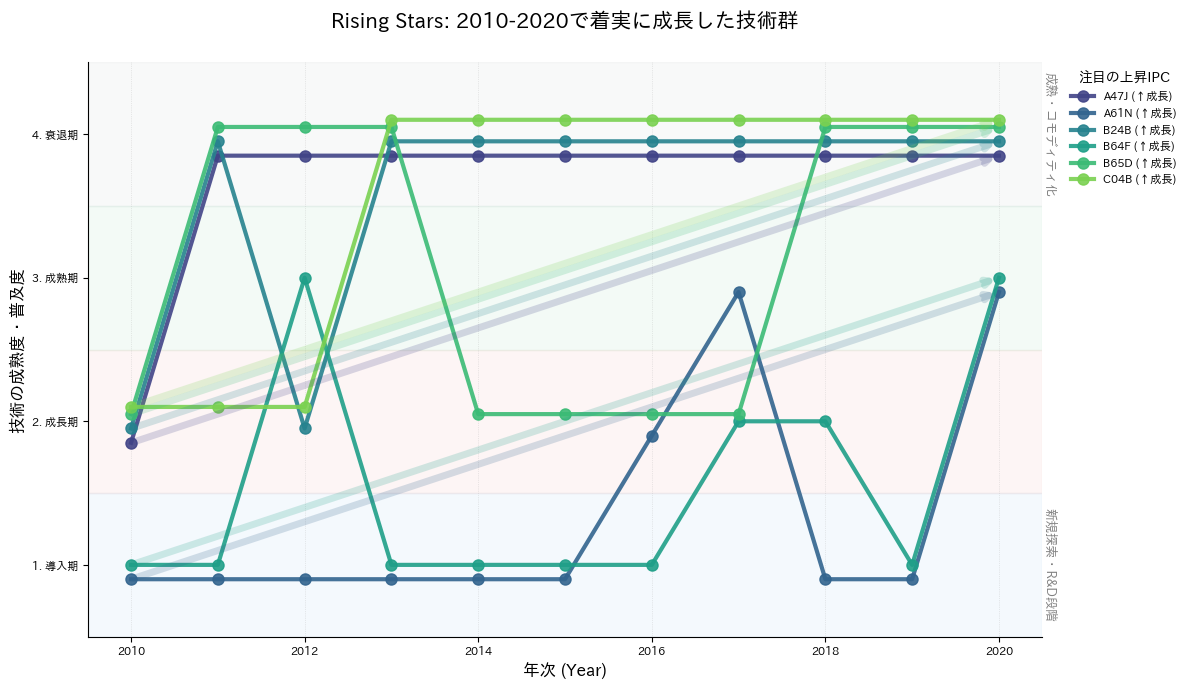

In [ ]:
def plot_rising_star_lifecycles(df_transitions, top_n=6):
    set_nature_style_jp()
    
    # 1. 象限のマッピング
    stage_map = {"1.導入期": 1, "2.成長期": 2, "3.成熟期": 3, "4.衰退期": 4}
    df_plot = df_transitions.copy()
    df_plot['Stage_Num'] = df_plot['Stage'].map(stage_map)
    
    # 年次ごとの代表ステージをピボット（最頻値）
    pivot_df = df_plot.groupby(['Year', 'IPC_Subclass'])['Stage_Num'].agg(lambda x: x.mode()[0]).unstack()
    
    # 2. 「上昇トレンド」を持つIPCの抽出
    rising_stars = []
    for ipc in pivot_df.columns:
        series = pivot_df[ipc].dropna()
        if len(series) >= 5:  # 5年以上データがあるもの
            # 開始時期と終了時期の差（成長量）を計算
            growth = series.iloc[-1] - series.iloc[0]
            # 途中で大きく下がっていないか（一貫性）も考慮
            if growth > 0:
                rising_stars.append((ipc, growth, series.count()))

    # 成長量とデータの長さでソートして上位を選択
    rising_stars.sort(key=lambda x: (x[1], x[2]), reverse=True)
    selected_ipcs = [x[0] for x in rising_stars[:top_n]]

    # 3. 描画
    fig, ax = plt.subplots(figsize=(12, 7))
    colors = plt.get_cmap('viridis')(np.linspace(0.2, 0.8, len(selected_ipcs)))
    
    for i, ipc in enumerate(selected_ipcs):
        series = pivot_df[ipc].dropna()
        # 重なり防止の微調整
        jitter = (i - len(selected_ipcs)/2) * 0.05
        
        # メインの線
        ax.plot(series.index, series.values + jitter, marker='o', label=f"{ipc} (↑成長)", 
                color=colors[i], lw=3, markersize=8, alpha=0.9)
        
        # 成長を強調する矢印（最初と最後を繋ぐ薄い影）
        ax.annotate('', xy=(series.index[-1], series.values[-1] + jitter), 
                    xytext=(series.index[0], series.values[0] + jitter),
                    arrowprops=dict(arrowstyle="->", color=colors[i], alpha=0.2, lw=5))

    # グラフ装飾
    ax.set_yticks([1, 2, 3, 4])
    ax.set_yticklabels(["1. 導入期", "2. 成長期", "3. 成熟期", "4. 衰退期"])
    ax.set_ylim(0.5, 4.5)
    ax.set_xlabel("年次 (Year)", fontsize=12, fontweight='bold')
    ax.set_ylabel("技術の成熟度・普及度", fontsize=12, fontweight='bold')
    ax.set_title("Rising Stars: 2010-2020で着実に成長した技術群", fontsize=15, pad=25, fontweight='bold')
    
    # 背景のカラー帯
    stage_colors = ['#3498db', '#e74c3c', '#27ae60', '#7f8c8d']
    for idx, c in enumerate(stage_colors):
        ax.axhspan(idx + 0.5, idx + 1.5, color=c, alpha=0.05)

    ax.grid(axis='x', linestyle=':', alpha=0.5)
    ax.legend(title="注目の上昇IPC", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    
    # 右端に「成長中」の矢印を追加
    ax.text(2020.5, 4, '成熟・コモディティ化', verticalalignment='center', rotation=270, color='gray', fontsize=9)
    ax.text(2020.5, 1, '新規探索・R&D段階', verticalalignment='center', rotation=270, color='gray', fontsize=9)

    plt.tight_layout()
    plt.show()

# 実行          
plot_rising_star_lifecycles(df_transitions, top_n=6)

In [50]:
import pandas as pd

def compare_patent_contents_robust(df, target_ipcs):
    print(f"[Analysis] 特許内容の抽出を開始します...")
    
    years_to_compare = [2010, 2020]
    final_data = []

    for ipc in target_ipcs:
        # 2010年と2020年のタイトルをそれぞれ取得
        year_titles = {}
        for year in years_to_compare:
            # 判定条件を少し緩める（大文字小文字無視、ストリップ）
            mask = (df['year'] == year) & (df['lead_ipc'].astype(str).str.contains(ipc, na=False))
            titles = df[mask]['patent_name'].unique().tolist()
            # 最大5件まで取得
            year_titles[year] = titles[:5]
        
        # 取得したリストの長さを揃えて表形式にする
        max_len = max(len(year_titles[2010]), len(year_titles[2020]))
        if max_len == 0:
            print(f"警告: {ipc} に一致する特許が 2010年/2020年に見つかりませんでした。")
            continue

        for i in range(max_len):
            final_data.append({
                'IPC': ipc,
                '順位': i + 1,
                '2010年の発明内容': year_titles[2010][i] if i < len(year_titles[2010]) else "-",
                '2020年の発明内容': year_titles[2020][i] if i < len(year_titles[2020]) else "-"
            })

    return pd.DataFrame(final_data)

# ============================================================
# 実行
# ============================================================
if 'df' in locals():
    targets = ["B24B", "A61N"]
    df_comp = compare_patent_contents_robust(df, targets)

    if not df_comp.empty:
        for ipc in targets:
            print(f"\n### 【{ipc}】 技術の10年間の進化")
            # IPCごとにフィルタリングして表示
            display(df_comp[df_comp['IPC'] == ipc][['順位', '2010年の発明内容', '2020年の発明内容']])
    else:
        print("抽出結果が空です。データの 'lead_ipc' カラムの形式を確認してください。")

[Analysis] 特許内容の抽出を開始します...
警告: B24B に一致する特許が 2010年/2020年に見つかりませんでした。
警告: A61N に一致する特許が 2010年/2020年に見つかりませんでした。
抽出結果が空です。データの 'lead_ipc' カラムの形式を確認してください。


In [52]:
import pandas as pd

def auto_compare_available_techs(df):
    print("--- 2010年と2020年の共通技術を探索中 ---")
    
    # 1. IPCのサブクラス（最初の4文字）を抽出
    df['subclass'] = df['lead_ipc'].astype(str).str[:4].str.strip()
    
    # 2. 2010年と2020年それぞれのIPC集合を作成
    ipcs_2010 = set(df[df['year'] == 2010]['subclass'].unique())
    ipcs_2020 = set(df[df['year'] == 2020]['subclass'].unique())
    
    # 3. 両方の年に存在するIPCを特定
    common_ipcs = list(ipcs_2010.intersection(ipcs_2020))
    # 'N/A' などを除外
    common_ipcs = [i for i in common_ipcs if len(i) == 4 and i != 'nan']
    
    print(f"両年に存在する共通IPC: {len(common_ipcs)}件発見")
    if not common_ipcs:
        print("共通するIPCが見つかりませんでした。個別に2020年の上位を表示します。")
        common_ipcs = list(ipcs_2020)[:3]
    
    # 4. 比較データの作成
    comparison_list = []
    for ipc in common_ipcs[:5]: # 上位5つのIPCを比較
        titles_2010 = df[(df['year'] == 2010) & (df['subclass'] == ipc)]['patent_name'].unique()[:3]
        titles_2020 = df[(df['year'] == 2020) & (df['subclass'] == ipc)]['patent_name'].unique()[:3]
        
        max_rows = max(len(titles_2010), len(titles_2020))
        for i in range(max_rows):
            comparison_list.append({
                '技術分類(IPC)': ipc,
                '2010年の発明': titles_2010[i] if i < len(titles_2010) else "-",
                '2020年の発明': titles_2020[i] if i < len(titles_2020) else "-"
            })
            
    return pd.DataFrame(comparison_list)

# 実行
df_auto_comp = auto_compare_available_techs(df)

if not df_auto_comp.empty:
    print("\n### 2010年 vs 2020年 技術進化の対比表")
    display(df_auto_comp)
else:
    print("表示できるデータがありません。")

--- 2010年と2020年の共通技術を探索中 ---
両年に存在する共通IPC: 72件発見

### 2010年 vs 2020年 技術進化の対比表


,技術分類(IPC),2010年の発明,2020年の発明
0,G01K,配管表面多点温度センサ及び流量計測用管,覆工コンクリートの温度測定装置
1,G01K,-,深部体温推定装置、深部体温推定方法、深部体温推定プログラム
2,A01M,海藻の食害防止具、及び、海藻の食害防止機能付きコンクリートブロック,法面水抜き孔の土砂流出防止構造
3,A01M,昆虫類侵入防止装置,-
4,A01M,獣害防止装置およびプログラム,-
5,C04B,スリップフォーム工法,水硬性組成物
6,C04B,ＣＯ２吸収プレキャストコンクリートおよびその製造方法,モルタルまたはコンクリート用混和材
7,C04B,中性化コンクリート成型体のアルカリ性回復剤及びアルカリ性回復方法,連続繊維補強材を使用した短繊維補強コンクリート構造物
8,C02F,汚染地下水の原位置浄化処理方法,泥水の脱水方法
9,C02F,濁水処理装置及び濁水処理方法,有機物処理装置、バイオガス生成システム及び汚水加熱装置



[Evaluation] 戦略的ランドスケープマップを作成中...
マップを保存しました: ./outputs/strategic_landscape_map.png


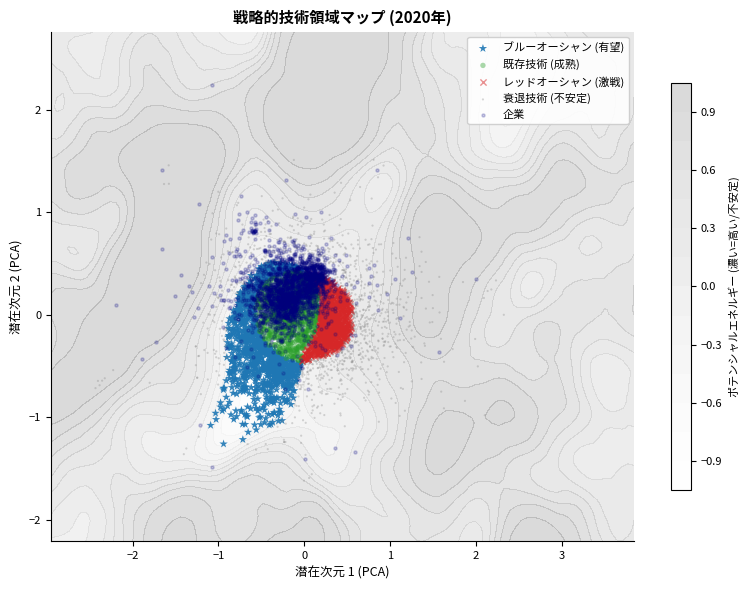

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import torch

# ============================================================
# 1. 日本語対応 Natureスタイル設定
# ============================================================
def set_nature_style_jp():
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': [
            'Hiragino Sans', 'Yu Gothic', 'Meiryo', 
            'Takao', 'IPAexGothic', 'IPAPGothic', 'VL PGothic', 
            'Noto Sans CJK JP', 'Arial', 'Helvetica', 'DejaVu Sans'
        ],
        'font.size': 10,
        'axes.labelsize': 9,
        'axes.titlesize': 11,
        'xtick.labelsize': 8,
        'ytick.labelsize': 8,
        'legend.fontsize': 8,
        'figure.figsize': (7.2, 5.0), # ダブルカラム幅に近い
        'axes.linewidth': 0.8,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'savefig.dpi': 300,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'svg.fonttype': 'none',  
    })

# ============================================================
# 2. 統合可視化関数: 戦略的ランドスケープマップ
# ============================================================
def visualize_strategic_landscape_map(model, config, num_corps, device, year_idx=-1):
    set_nature_style_jp()
    print("\n[Evaluation] 戦略的ランドスケープマップを作成中...")
    
    # --- 1. データ準備 ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    # ポテンシャルネットワーク取得
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Potential Net not found.")
        return

    # エンコード
    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            diff = expected_dim - x_input.shape[1]
            if diff > 0:
                padding = torch.zeros((x_input.shape[0], diff), device=device)
                x_input = torch.cat([x_input, padding], dim=1)
            else:
                x_input = x_input[:, :expected_dim]
                
        z, _, _ = model.encode(x_input, data.edge_index)
        z_np = z.cpu().numpy()
        
        # ポテンシャル値（全データ）
        potentials_all = pot_net(z).squeeze().cpu().numpy()

    # --- 2. 特許データに基づく4象限分類 ---
    # 特許のみ抽出
    patent_indices = np.arange(num_corps, len(z_np))
    patent_z = z_np[patent_indices]
    patent_potentials = potentials_all[patent_indices]
    
    # PCA (2次元投影)
    pca = PCA(n_components=2)
    z_all_2d = pca.fit_transform(z_np) # 全体でPCA
    patent_z_2d = z_all_2d[patent_indices] # 特許部分のみ
    
    # 密度推定 (KDE)
    try:
        kde = gaussian_kde(patent_z_2d.T)
        patent_densities = kde(patent_z_2d.T)
    except Exception as e:
        print(f"Error in KDE: {e}")
        return

    # しきい値決定 (中央値)
    pot_thr = np.median(patent_potentials)
    den_thr = np.median(patent_densities)
    
    # 特許ごとの象限ラベル付け
    # 0: ブルーオーシャン (Pot:Low, Den:Low)
    # 1: 既存技術 (Pot:Low, Den:High)
    # 2: レッドオーシャン (Pot:High, Den:High)
    # 3: 衰退技術 (Pot:High, Den:Low)
    patent_labels = np.zeros(len(patent_indices), dtype=int)
    
    mask_blue = (patent_potentials <= pot_thr) & (patent_densities <= den_thr)
    mask_main = (patent_potentials <= pot_thr) & (patent_densities > den_thr)
    mask_red = (patent_potentials > pot_thr) & (patent_densities > den_thr)
    mask_decline = (patent_potentials > pot_thr) & (patent_densities <= den_thr)
    
    patent_labels[mask_blue] = 0
    patent_labels[mask_main] = 1
    patent_labels[mask_red] = 2
    patent_labels[mask_decline] = 3

    # --- 3. 背景のポテンシャル地形計算 ---
    x_min, x_max = z_all_2d[:, 0].min(), z_all_2d[:, 0].max()
    y_min, y_max = z_all_2d[:, 1].min(), z_all_2d[:, 1].max()
    margin = 0.5
    
    grid_res = 100
    grid_x = np.linspace(x_min - margin, x_max + margin, grid_res)
    grid_y = np.linspace(y_min - margin, y_max + margin, grid_res)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_16d = pca.inverse_transform(grid_flat_2d)
    grid_tensor = torch.tensor(grid_flat_16d, dtype=torch.float32).to(device)
    
    with torch.no_grad():
        Z_pot = pot_net(grid_tensor).squeeze().cpu().numpy().reshape(X.shape)

    # --- 4. プロット ---
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # 背景: ポテンシャル等高線 (薄く)
    contour = ax.contourf(X, Y, Z_pot, levels=15, cmap='Greys', alpha=0.15)
    
    # 色設定 (4象限分類と合わせる)
    colors = ['#1f77b4', '#2ca02c', '#d62728', '#7f7f7f']
    labels = ['ブルーオーシャン (有望)', '既存技術 (成熟)', 'レッドオーシャン (激戦)', '衰退技術 (不安定)']
    markers = ['*', 'o', 'x', '.']
    sizes = [40, 15, 20, 10]
    alphas = [0.9, 0.4, 0.5, 0.3]
    
    # 象限ごとに特許をプロット
    for i in range(4):
        mask = (patent_labels == i)
        # データが多すぎる場合はサンプリング
        if np.sum(mask) > 1000:
            indices = np.where(mask)[0]
            sampled_indices = np.random.choice(indices, 1000, replace=False)
            p_z = patent_z_2d[sampled_indices]
        else:
            p_z = patent_z_2d[mask]
            
        ax.scatter(p_z[:, 0], p_z[:, 1], c=colors[i], label=labels[i], 
                   marker=markers[i], s=sizes[i], alpha=alphas[i], edgecolors='none')

    # 企業 (青い点, 透明度高め)
    corp_z_2d = z_all_2d[:num_corps]
    ax.scatter(corp_z_2d[:, 0], corp_z_2d[:, 1], c='navy', s=5, alpha=0.2, label='企業', zorder=1)

    # 凡例と装飾
    ax.legend(loc='upper right', frameon=True, framealpha=0.9)
    ax.set_title(f"戦略的技術領域マップ ({target_year}年)", fontweight='bold')
    ax.set_xlabel("潜在次元 1 (PCA)")
    ax.set_ylabel("潜在次元 2 (PCA)")
    
    # カラーバー (ポテンシャルの高低を示す)
    cbar = plt.colorbar(contour, ax=ax, shrink=0.8)
    cbar.set_label('ポテンシャルエネルギー (濃い=高い/不安定)', fontsize=8)

    plt.tight_layout()
    
    # 保存
    plt.savefig('./outputs/strategic_landscape_map.svg', format='svg', bbox_inches='tight')
    plt.savefig('./outputs/strategic_landscape_map.png', dpi=300)
    print("マップを保存しました: ./outputs/strategic_landscape_map.png")
    plt.show()

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    if 'config' in locals() and 'model' in locals():
        visualize_strategic_landscape_map(
            model, config, 
            num_corps=config['num_corps'], 
            device=device
        )


[Evaluation] 戦略的ランドスケープ (地形なし・ベクトルのみ) を作成中...
保存完了: ./outputs/strategic_landscape_clean_vectors.png


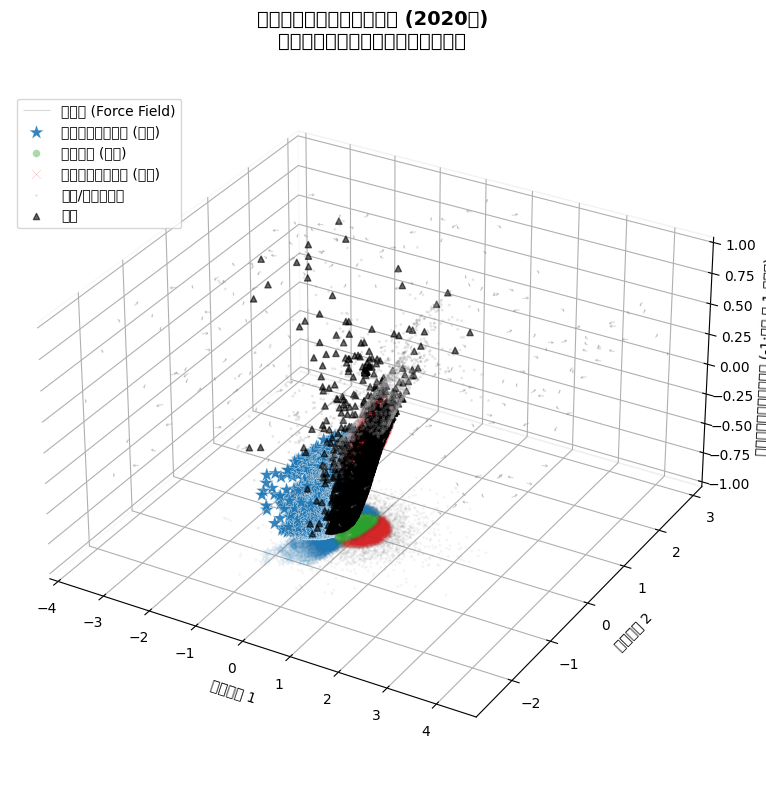

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
import torch
import japanize_matplotlib # 日本語表示用

# ============================================================
# 1. Nature Style Configuration (3D + JP)
# ============================================================
def set_nature_style_3d_jp():
    plt.style.use('default')
    plt.rcParams.update({
        'font.size': 10,
        'savefig.dpi': 300,
        'figure.figsize': (10, 8),
        'svg.fonttype': 'none',
        # japanize_matplotlibが適用されるためフォント指定は省略
    })

# ============================================================
# 2. 統合可視化関数 (地形なし・ベクトルのみ)
# ============================================================
def visualize_strategic_landscape_clean(model, config, num_corps, device, year_idx=-1):
    set_nature_style_3d_jp()
    print("\n[Evaluation] 戦略的ランドスケープ (地形なし・ベクトルのみ) を作成中...")
    
    # --- 1. データ準備 ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Potential Net not found.")
        return

    # エンコード
    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            diff = expected_dim - x_input.shape[1]
            if diff > 0:
                x_input = torch.cat([x_input, torch.zeros((x_input.shape[0], diff), device=device)], dim=1)
            else:
                x_input = x_input[:, :expected_dim]
                
        z, _, _ = model.encode(x_input, data.edge_index)
        z_np = z.cpu().numpy()
        
        # 生のポテンシャル値
        potentials_raw = pot_net(z).squeeze().cpu().numpy()

    # --- 2. 座標系構築 (PCA 2D) ---
    pca = PCA(n_components=2)
    xy_coords = pca.fit_transform(z_np)
    
    x_min, x_max = xy_coords[:, 0].min(), xy_coords[:, 0].max()
    y_min, y_max = xy_coords[:, 1].min(), xy_coords[:, 1].max()
    
    # --- 3. ベクトル場の計算 ---
    margin = 0.2
    x_range = x_max - x_min
    y_range = y_max - y_min
    grid_res = 30 # ベクトル描画用の解像度
    
    grid_x = np.linspace(x_min - x_range*margin, x_max + x_range*margin, grid_res)
    grid_y = np.linspace(y_min - y_range*margin, y_max + y_range*margin, grid_res)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_high = pca.inverse_transform(grid_flat_2d)
    grid_tensor = torch.tensor(grid_flat_high, dtype=torch.float32).to(device)
    
    grid_tensor.requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = pot_net(grid_tensor)
        grad = torch.autograd.grad(phi.sum(), grid_tensor, create_graph=False)[0]
    
    grad_np = grad.cpu().numpy()
    grad_2d = np.dot(grad_np, pca.components_.T)
    
    # ベクトル成分 (-勾配 = 安定方向への流れ)
    U = -grad_2d[:, 0].reshape(X.shape)
    V = -grad_2d[:, 1].reshape(X.shape)
    Z_raw_grid = phi.detach().cpu().numpy().reshape(X.shape)

    # --- 4. ポテンシャル正規化 (-1 ~ 1) ---
    all_z = np.concatenate([Z_raw_grid.flatten(), potentials_raw.flatten()])
    z_min_val, z_max_val = all_z.min(), all_z.max()
    
    def normalize_m1_1(val):
        # -1(谷/安定) 〜 1(山/不安定) に正規化
        return -1 + 2 * (val - z_min_val) / (z_max_val - z_min_val)

    Z_grid_norm = normalize_m1_1(Z_raw_grid)
    nodes_z_norm = normalize_m1_1(potentials_raw)

    # --- 5. 4象限分類ロジック (密度 & 正規化ポテンシャル) ---
    patent_indices = np.arange(num_corps, len(z_np))
    patent_xy = xy_coords[patent_indices]
    
    # 密度計算
    try:
        if len(patent_xy) > 5000:
            idx = np.random.choice(len(patent_xy), 5000, replace=False)
            kde = gaussian_kde(patent_xy[idx].T)
        else:
            kde = gaussian_kde(patent_xy.T)
        patent_densities = kde(patent_xy.T)
    except:
        patent_densities = np.zeros(len(patent_xy))

    # しきい値
    p_pot_norm = nodes_z_norm[patent_indices]
    pot_thr = np.median(p_pot_norm)
    den_thr = np.median(patent_densities)
    
    labels = np.zeros(len(patent_indices), dtype=int)
    
    # 0: ブルーオーシャン (Pot:Low[-1], Den:Low)
    labels[(p_pot_norm <= pot_thr) & (patent_densities <= den_thr)] = 0
    # 1: 既存技術 (Pot:Low[-1], Den:High)
    labels[(p_pot_norm <= pot_thr) & (patent_densities > den_thr)] = 1
    # 2: レッドオーシャン (Pot:High[1], Den:High)
    labels[(p_pot_norm > pot_thr) & (patent_densities > den_thr)] = 2
    # 3: 衰退/リスク (Pot:High[1], Den:Low)
    labels[(p_pot_norm > pot_thr) & (patent_densities <= den_thr)] = 3

    # ================= Plotting =================
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # A. ベクトル場 (地形なしで、空中に矢印だけ浮かべる)
    # 矢印の高さを、その地点のポテンシャルエネルギーに合わせる
    skip = 2 # 間引き
    ax.quiver(X[::skip, ::skip], Y[::skip, ::skip], Z_grid_norm[::skip, ::skip], 
              U[::skip, ::skip], V[::skip, ::skip], np.zeros_like(U[::skip, ::skip]), 
              length=0.1, normalize=True, color='gray', alpha=0.3, 
              arrow_length_ratio=0.4, linewidth=0.8, label='駆動力 (Force Field)')

    # B. 散布図 (4象限分類)
    colors = ['#1f77b4', '#2ca02c', '#d62728', '#7f7f7f']
    names = ['ブルーオーシャン (有望)', '既存技術 (成熟)', 'レッドオーシャン (激戦)', '衰退/リスク領域']
    markers = ['*', 'o', 'x', '.']
    sizes = [120, 30, 40, 15] 
    alphas = [0.9, 0.4, 0.5, 0.2]
    
    z_floor = -1.0 # 床の高さ
    
    for i in range(4):
        mask = (labels == i)
        # 描画点数を制限
        if np.sum(mask) > 1500:
            indices = np.where(mask)[0]
            sampled = np.random.choice(indices, 1500, replace=False)
            px, py = patent_xy[sampled, 0], patent_xy[sampled, 1]
            pz = nodes_z_norm[patent_indices][sampled]
        else:
            px, py = patent_xy[mask, 0], patent_xy[mask, 1]
            pz = nodes_z_norm[patent_indices][mask]
            
        # データ点 (空中に浮いている)
        ax.scatter(px, py, pz, c=colors[i], label=names[i], 
                   marker=markers[i], s=sizes[i], alpha=alphas[i], 
                   depthshade=True, edgecolors='white', linewidth=0.2)
        
        # 床への影 (これが重要: 地形がないため、影で高さを認識させる)
        ax.scatter(px, py, np.full_like(pz, z_floor), 
                   c=colors[i], marker=markers[i], s=sizes[i]/3, alpha=0.05)

    # C. 企業 (黒い三角)
    c_idx = np.arange(num_corps)
    cx, cy = xy_coords[c_idx, 0], xy_coords[c_idx, 1]
    cz = nodes_z_norm[c_idx]
    ax.scatter(cx, cy, cz, c='black', label='企業', marker='^', s=20, alpha=0.6)

    # --- 見た目の調整 ---
    ax.set_title(f"戦略的技術ランドスケープ ({target_year}年)\n〜ベクトル場と市場ポテンシャル〜", 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('潜在変数 1')
    ax.set_ylabel('潜在変数 2')
    ax.set_zlabel('ポテンシャルエネルギー (-1:安定 〜 1:不安定)')
    
    # Z軸を -1 ~ 1 に固定
    ax.set_zlim(-1.0, 1.0)
    
    # 視点
    ax.view_init(elev=30, azim=-60)
    
    # 背景透明化
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.grid(True, linestyle=':', alpha=0.3)
    ax.set_box_aspect((1, 1, 0.6))

    # 凡例
    plt.legend(loc='upper left', bbox_to_anchor=(0, 0.95), frameon=True)
    
    plt.tight_layout()
    
    # 保存
    plt.savefig('./outputs/strategic_landscape_clean_vectors.svg', format='svg', bbox_inches='tight')
    plt.savefig('./outputs/strategic_landscape_clean_vectors.png', dpi=300)
    print("保存完了: ./outputs/strategic_landscape_clean_vectors.png")
    plt.show()

if __name__ == "__main__":
    if 'config' in locals() and 'model' in locals():
        visualize_strategic_landscape_clean(
            model, config, 
            num_corps=config['num_corps'], 
            device=device
        )


[Evaluation] 戦略的ランドスケープ (3D統合版) を作成中...
保存完了: ./outputs/strategic_landscape_3d_integrated.png


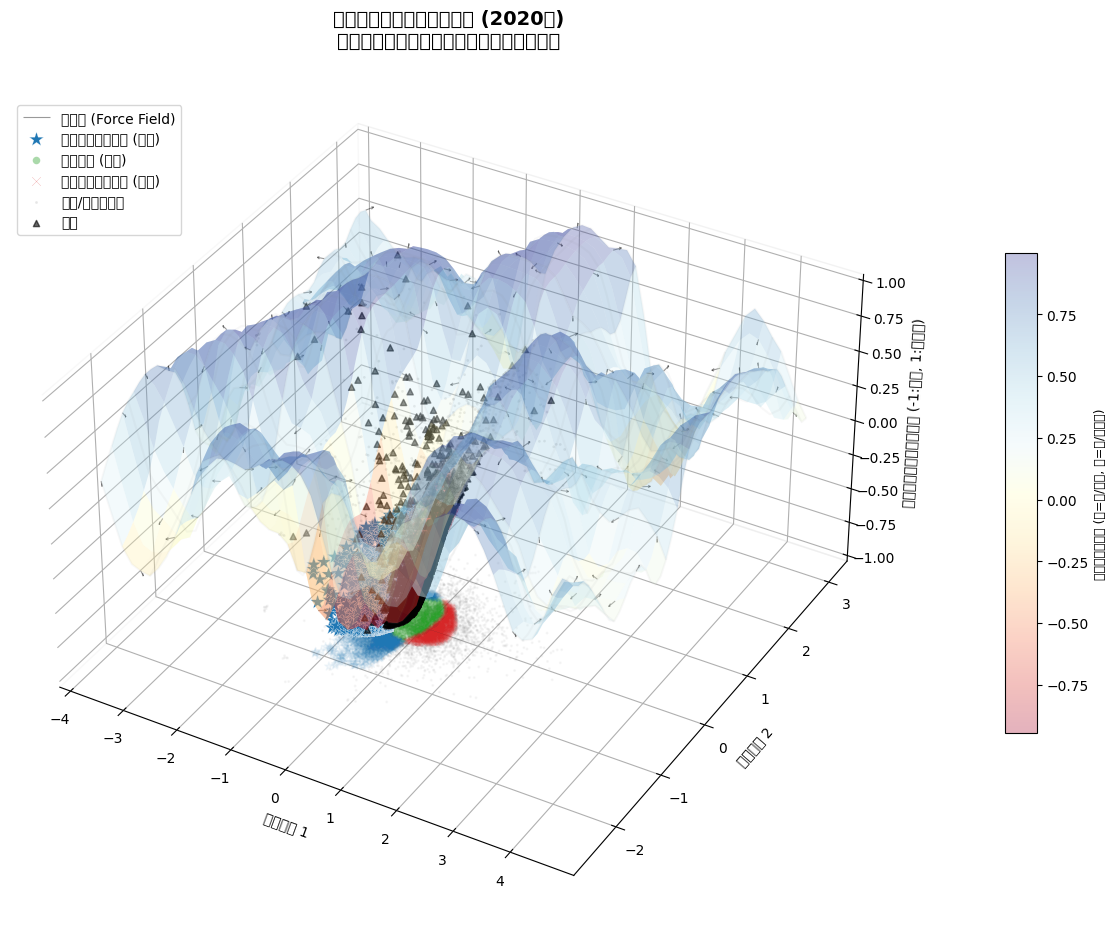

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import torch
import japanize_matplotlib # 日本語表示用

# ============================================================
# 1. Nature Style Configuration (3D + JP)
# ============================================================
def set_nature_style_3d_jp():
    plt.style.use('default')
    plt.rcParams.update({
        'font.size': 10,
        'savefig.dpi': 300,
        'figure.figsize': (10, 8),
        'svg.fonttype': 'none',
        # japanize_matplotlibが適用されるためフォント指定は省略可能ですが
        # 必要であれば以下のように指定
        # 'font.family': 'IPAexGothic',
    })

# ============================================================
# 2. 統合可視化関数 (3D + ベクトル + 4象限分類)
# ============================================================
def visualize_strategic_landscape_3d_integrated(model, config, num_corps, device, year_idx=-1):
    set_nature_style_3d_jp()
    print("\n[Evaluation] 戦略的ランドスケープ (3D統合版) を作成中...")
    
    # --- 1. データ準備 ---
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Potential Net not found.")
        return

    # エンコード
    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            diff = expected_dim - x_input.shape[1]
            if diff > 0:
                x_input = torch.cat([x_input, torch.zeros((x_input.shape[0], diff), device=device)], dim=1)
            else:
                x_input = x_input[:, :expected_dim]
                
        z, _, _ = model.encode(x_input, data.edge_index)
        z_np = z.cpu().numpy()
        
        # 生のポテンシャル値
        potentials_raw = pot_net(z).squeeze().cpu().numpy()

    # --- 2. 座標系構築 (PCA 2D) ---
    pca = PCA(n_components=2)
    xy_coords = pca.fit_transform(z_np)
    
    x_min, x_max = xy_coords[:, 0].min(), xy_coords[:, 0].max()
    y_min, y_max = xy_coords[:, 1].min(), xy_coords[:, 1].max()
    
    # --- 3. ベクトル場 & 地形の計算 ---
    margin = 0.2
    x_range = x_max - x_min
    y_range = y_max - y_min
    grid_res = 50 # 解像度
    
    grid_x = np.linspace(x_min - x_range*margin, x_max + x_range*margin, grid_res)
    grid_y = np.linspace(y_min - y_range*margin, y_max + y_range*margin, grid_res)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_high = pca.inverse_transform(grid_flat_2d)
    grid_tensor = torch.tensor(grid_flat_high, dtype=torch.float32).to(device)
    
    grid_tensor.requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = pot_net(grid_tensor)
        grad = torch.autograd.grad(phi.sum(), grid_tensor, create_graph=False)[0]
    
    grad_np = grad.cpu().numpy()
    grad_2d = np.dot(grad_np, pca.components_.T)
    
    # ベクトル成分 (-勾配 = 谷へ下る方向)
    U = -grad_2d[:, 0].reshape(X.shape)
    V = -grad_2d[:, 1].reshape(X.shape)
    Z_raw_grid = phi.detach().cpu().numpy().reshape(X.shape)

    # --- 4. ポテンシャル正規化 (-1 ~ 1) ---
    all_z = np.concatenate([Z_raw_grid.flatten(), potentials_raw.flatten()])
    z_min_val, z_max_val = all_z.min(), all_z.max()
    
    def normalize_m1_1(val):
        return -1 + 2 * (val - z_min_val) / (z_max_val - z_min_val)

    Z_grid_norm = normalize_m1_1(Z_raw_grid)
    nodes_z_norm = normalize_m1_1(potentials_raw)

    # --- 5. 4象限分類ロジック (密度 & ポテンシャル) ---
    patent_indices = np.arange(num_corps, len(z_np))
    patent_xy = xy_coords[patent_indices]
    
    # 密度計算 (KDE)
    try:
        if len(patent_xy) > 5000:
            idx = np.random.choice(len(patent_xy), 5000, replace=False)
            kde = gaussian_kde(patent_xy[idx].T)
        else:
            kde = gaussian_kde(patent_xy.T)
        patent_densities = kde(patent_xy.T)
    except:
        patent_densities = np.zeros(len(patent_xy))

    # しきい値 (中央値)
    p_pot = potentials_raw[patent_indices] # 生の値で判定するのが安全
    pot_thr = np.median(p_pot)
    den_thr = np.median(patent_densities)
    
    labels = np.zeros(len(patent_indices), dtype=int)
    # 0: ブルーオーシャン (Pot:Low, Den:Low) -> 安定かつ空いている
    labels[(p_pot <= pot_thr) & (patent_densities <= den_thr)] = 0
    # 1: 既存技術 (Pot:Low, Den:High) -> 安定だが混んでいる
    labels[(p_pot <= pot_thr) & (patent_densities > den_thr)] = 1
    # 2: レッドオーシャン (Pot:High, Den:High) -> 不安定かつ混んでいる
    labels[(p_pot > pot_thr) & (patent_densities > den_thr)] = 2
    # 3: 衰退技術/リスク (Pot:High, Den:Low) -> 不安定かつ空いている
    labels[(p_pot > pot_thr) & (patent_densities <= den_thr)] = 3

    # ================= Plotting =================
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # A. 地形 (Surface) - 山=青, 谷=赤
    surf = ax.plot_surface(X, Y, Z_grid_norm, cmap='RdYlBu', alpha=0.3, 
                           linewidth=0, antialiased=True, rstride=2, cstride=2)
    
    # B. ワイヤーフレーム (形状強調)
    ax.plot_wireframe(X, Y, Z_grid_norm, color='gray', alpha=0.05, rstride=5, cstride=5)

    # C. ベクトル場 (矢印)
    skip = 4
    ax.quiver(X[::skip, ::skip], Y[::skip, ::skip], Z_grid_norm[::skip, ::skip], 
              U[::skip, ::skip], V[::skip, ::skip], np.zeros_like(U[::skip, ::skip]), 
              length=0.12, normalize=True, color='black', alpha=0.4, 
              arrow_length_ratio=0.3, linewidth=0.8, label='駆動力 (Force Field)')

    # D. 散布図 (4象限)
    colors = ['#1f77b4', '#2ca02c', '#d62728', '#7f7f7f']
    names = ['ブルーオーシャン (有望)', '既存技術 (成熟)', 'レッドオーシャン (激戦)', '衰退/リスク領域']
    markers = ['*', 'o', 'x', '.']
    sizes = [120, 30, 40, 15] # ブルーオーシャンを強調
    alphas = [1.0, 0.4, 0.5, 0.2]
    
    z_floor = -1.0 # 床の高さ
    
    for i in range(4):
        mask = (labels == i)
        # 描画点数を制限して見やすくする
        if np.sum(mask) > 1500:
            indices = np.where(mask)[0]
            sampled = np.random.choice(indices, 1500, replace=False)
            px, py = patent_xy[sampled, 0], patent_xy[sampled, 1]
            pz = nodes_z_norm[patent_indices][sampled]
        else:
            px, py = patent_xy[mask, 0], patent_xy[mask, 1]
            pz = nodes_z_norm[patent_indices][mask]
            
        # データ点
        ax.scatter(px, py, pz, c=colors[i], label=names[i], 
                   marker=markers[i], s=sizes[i], alpha=alphas[i], 
                   depthshade=True, edgecolors='white', linewidth=0.2)
        
        # 床への影 (位置関係把握用)
        ax.scatter(px, py, np.full_like(pz, z_floor), 
                   c=colors[i], marker=markers[i], s=sizes[i]/3, alpha=0.05)

    # E. 企業 (黒い三角)
    c_idx = np.arange(num_corps)
    cx, cy = xy_coords[c_idx, 0], xy_coords[c_idx, 1]
    cz = nodes_z_norm[c_idx]
    ax.scatter(cx, cy, cz, c='black', label='企業', marker='^', s=20, alpha=0.6)

    # --- 見た目の調整 ---
    ax.set_title(f"戦略的技術ランドスケープ ({target_year}年)\n〜ポテンシャル場と市場密度による分析〜", 
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('潜在変数 1')
    ax.set_ylabel('潜在変数 2')
    ax.set_zlabel('ポテンシャルエネルギー (-1:安定, 1:不安定)')
    ax.set_zlim(-1.0, 1.0)
    
    # 視点
    ax.view_init(elev=35, azim=-60)
    
    # 背景透明化
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.grid(True, linestyle=':', alpha=0.3)
    ax.set_box_aspect((1, 1, 0.6))

    # カラーバー
    cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=15, pad=0.1)
    cbar.set_label('エネルギー準位 (赤=谷/安定, 青=山/不安定)', fontsize=9)

    plt.legend(loc='upper left', bbox_to_anchor=(0, 0.95), frameon=True)
    
    plt.tight_layout()
    
    # 保存
    plt.savefig('./outputs/strategic_landscape_3d_integrated.svg', format='svg', bbox_inches='tight')
    plt.savefig('./outputs/strategic_landscape_3d_integrated.png', dpi=300)
    print("保存完了: ./outputs/strategic_landscape_3d_integrated.png")
    plt.show()

if __name__ == "__main__":
    if 'config' in locals() and 'model' in locals():
        visualize_strategic_landscape_3d_integrated(
            model, config, 
            num_corps=config['num_corps'], 
            device=device
        )

Loading data from ../dataset/topic_info3.csv...
Training Standard GODE...
Epoch 1/15 | Loss: 23.5525
Epoch 2/15 | Loss: 11.4278
Epoch 3/15 | Loss: 8.7772
Epoch 4/15 | Loss: 7.2759
Epoch 5/15 | Loss: 7.2415
Epoch 6/15 | Loss: 7.0361
Epoch 7/15 | Loss: 6.9904
Epoch 8/15 | Loss: 6.9772
Epoch 9/15 | Loss: 6.9264
Epoch 10/15 | Loss: 6.9283
Epoch 11/15 | Loss: 6.8997
Epoch 12/15 | Loss: 6.9468
Epoch 13/15 | Loss: 6.9271
Epoch 14/15 | Loss: 6.9376
Epoch 15/15 | Loss: 6.9232

Visualizing Year: 2020

Generating Vector Field for Standard GODE (SVG Output)...
Visualization saved to ./standard_ode_vector_field_2020.svg


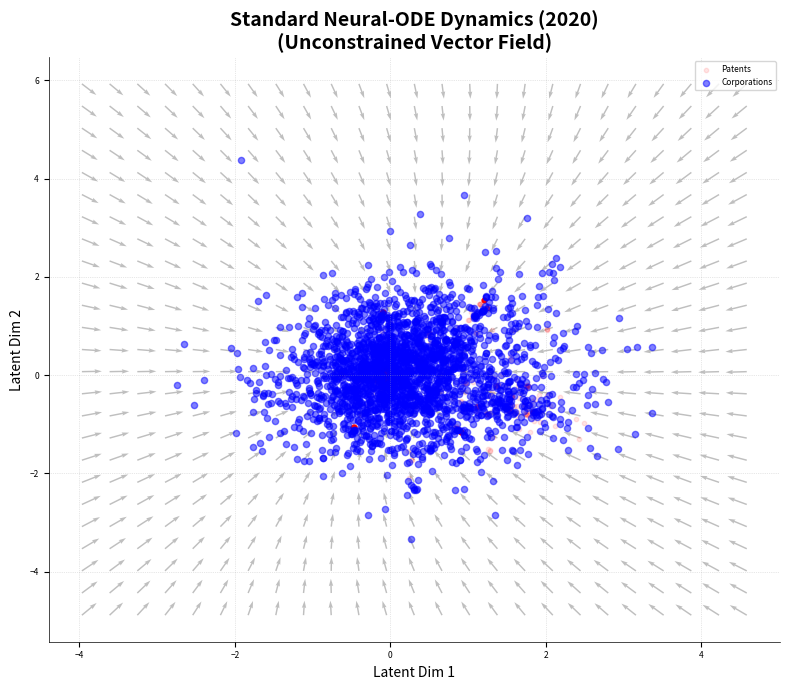

In [ ]:
import time
import pandas as pd
import numpy as np
import ast
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint_adjoint as odeint
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import warnings
import os

# ============================================================
# 基本設定
# ============================================================
warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 1. データ前処理 & グラフ構築
# ============================================================
def safe_parse_embedding(x):
    if pd.isna(x) or x == "": return None
    if isinstance(x, (list, np.ndarray)): return np.array(x, dtype=np.float32)
    if isinstance(x, str):
        try:
            s = re.sub(r'[\[\]\n]', '', x)
            s = s.replace(',', ' ')
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except: return None
    return None

def preprocess_and_build_graphs(file_path):
    print(f"Loading data from {file_path}...")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
        return None, None, None, None

    combined_vectors = []
    valid_indices = []
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row.get('description_embedding', ''))
        meta = safe_parse_embedding(row.get('metadata_embedding', ''))
        if desc is not None and meta is not None:
            combined_vectors.append(np.concatenate([desc, meta]))
            valid_indices.append(i)
    
    df = df.iloc[valid_indices].copy()
    df['combined_vector'] = combined_vectors
    
    def parse_corp(x):
        try: return ast.literal_eval(x) if isinstance(x, str) else x
        except: return [x] if isinstance(x, str) else x
    
    if "corporation" in df.columns:
        df["corporation"] = df["corporation"].apply(parse_corp)
    
    if "year_month" in df.columns:
        df['year_month'] = pd.to_datetime(df['year_month'], errors='coerce')
        df = df.dropna(subset=['year_month'])
        df = df[(df['year_month'] >= '2010-01-01') & (df['year_month'] <= '2020-12-31')]

    # グラフ構築
    all_corporations = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    corp_to_idx = {corp: i for i, corp in enumerate(all_corporations)}
    patent_to_idx = {patent: i + len(all_corporations) for i, patent in enumerate(all_patents)}
    total_nodes = len(all_corporations) + len(all_patents)
    
    patent_features = {}
    for _, row in df.iterrows():
        patent_features[row['patent_number']] = row['combined_vector']
    input_dim = len(next(iter(patent_features.values()))) if patent_features else 10

    global_graph_dict = {}
    for year, group in df.groupby(df['year_month'].dt.year):
        edges = []
        for _, row in group.iterrows():
            if row['patent_number'] not in patent_to_idx: continue
            p_idx = patent_to_idx[row['patent_number']]
            for corp in row['corporation']:
                if corp in corp_to_idx:
                    c_idx = corp_to_idx[corp]
                    edges.append([c_idx, p_idx])
                    edges.append([p_idx, c_idx])
        
        if not edges: continue
        x = torch.zeros(total_nodes, input_dim)
        for p_num, p_idx in patent_to_idx.items():
            if p_num in patent_features: x[p_idx] = torch.tensor(patent_features[p_num])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        global_graph_dict[year] = Data(x=x, edge_index=edge_index, num_nodes=total_nodes)

    return global_graph_dict, len(all_corporations), total_nodes, input_dim

# ============================================================
# 2. モデル定義 (Standard GODE & Encoder)
# ============================================================
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv_mu = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)

    def forward(self, x, edge_index):
        x = F.elu(self.conv1(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

class ODEFuncNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, latent_dim),
            nn.Tanh()
        )
    def forward(self, t, z):
        return self.net(z)

class StandardGODE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.ode_func_module = ODEFuncNet(latent_dim, hidden_dim)

    def get_node_features(self, x):
        features = x.clone()
        node_indices = torch.arange(self.num_nodes, device=x.device)
        corp_idx = node_indices[node_indices < self.num_corps]
        features[corp_idx] = self.corp_embeddings(corp_idx)
        return features

    def encode(self, x, edge_index):
        x = self.get_node_features(x)
        mu, logvar = self.encoder(x, edge_index)
        z = mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)
        return z, mu, logvar

    def predict_future(self, z_curr):
        t_span = torch.tensor([0., 1.0], device=z_curr.device)
        z_next = odeint(self.ode_func_module, z_curr, t_span, method='dopri5')[-1]
        return z_next

    def decode(self, z, edge_index):
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        return torch.sigmoid((z_src * z_dst).sum(dim=1))

# ============================================================
# 3. 学習関数 (Standard GODE専用)
# ============================================================
def train_standard_ode(model, graphs, num_epochs=15):
    print("Training Standard GODE...")
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    years = sorted(graphs.keys())
    train_years = years[:-1]

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        
        for i in range(len(train_years) - 1):
            y_t = train_years[i]
            y_next = train_years[i+1]
            data_t = graphs[y_t].to(device)
            data_next = graphs[y_next].to(device)

            optimizer.zero_grad()
            
            # Encode & Recon
            z_t, _, _ = model.encode(data_t.x, data_t.edge_index)
            pos_pred = model.decode(z_t, data_t.edge_index)
            neg_idx = torch.randint(0, model.num_nodes, data_t.edge_index.size(), device=device)
            neg_pred = model.decode(z_t, neg_idx)
            recon_loss = -torch.log(pos_pred + 1e-9).mean() - torch.log(1 - neg_pred + 1e-9).mean()
            
            # Future Prediction (MSE)
            # Standard ODEは「何でもあり」の動きをするため、この項で無理やり合わせようとする
            z_pred = model.predict_future(z_t)
            with torch.no_grad():
                _, mu_next, _ = model.encode(data_next.x, data_next.edge_index)
            
            # MSE Loss
            loss_pred = F.mse_loss(z_pred, mu_next)
            
            total_loss = recon_loss + loss_pred
            total_loss.backward()
            optimizer.step()
            epoch_loss += total_loss.item()
            
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {epoch_loss:.4f}")
    
    return model

# ============================================================
# 4. 可視化関数 (ベクトル場 - SVG保存)
# ============================================================
def visualize_standard_ode_2d(model, data, num_corps, device):
    print("\nGenerating Vector Field for Standard GODE (SVG Output)...")
    model.eval()
    data = data.to(device)
    
    # 1. Encode
    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            x_input = torch.cat([x_input, torch.zeros((data.x.shape[0], expected_dim - x_input.shape[1]), device=device)], dim=1)
        z, _, _ = model.encode(x_input, data.edge_index)
        z_np = z.cpu().numpy()

    # 2. PCA
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    
    # 3. Grid
    x_min, x_max = z_2d[:, 0].min(), z_2d[:, 0].max()
    y_min, y_max = z_2d[:, 1].min(), z_2d[:, 1].max()
    margin_x = (x_max - x_min) * 0.2
    margin_y = (y_max - y_min) * 0.2
    
    resolution = 25
    grid_x = np.linspace(x_min - margin_x, x_max + margin_x, resolution)
    grid_y = np.linspace(y_min - margin_y, y_max + margin_y, resolution)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_high = pca.inverse_transform(grid_flat_2d)
    grid_tensor = torch.tensor(grid_flat_high, dtype=torch.float32).to(device)
    
    # 4. Vector Field (dz/dt)
    with torch.no_grad():
        dz_dt = model.ode_func_module(torch.tensor(0.0), grid_tensor)
    
    dz_dt_2d = np.dot(dz_dt.cpu().numpy(), pca.components_.T)
    U = dz_dt_2d[:, 0].reshape(X.shape)
    V = dz_dt_2d[:, 1].reshape(X.shape)

    # 5. Plot
    fig, ax = plt.subplots(figsize=(8, 7))
    
    # Quiver (ベクトル場)
    ax.quiver(X, Y, U, V, color='gray', alpha=0.5, angles='xy', scale_units='xy', width=0.002)
    
    # Scatter (データ点)
    ax.scatter(z_2d[num_corps:, 0], z_2d[num_corps:, 1], c='red', alpha=0.1, s=10, label='Patents')
    ax.scatter(z_2d[:num_corps, 0], z_2d[:num_corps, 1], c='blue', alpha=0.5, s=20, label='Corporations')

    ax.set_title("Standard Neural-ODE Dynamics (2020)\n(Unconstrained Vector Field)", fontsize=14, fontweight='bold')
    ax.set_xlabel('Latent Dim 1', fontsize=10)
    ax.set_ylabel('Latent Dim 2', fontsize=10)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # === SVGで保存 ===
    save_path = './standard_ode_vector_field_2020.svg' # ファイル名に2020を追加
    plt.tight_layout()
    plt.savefig(save_path, format='svg', bbox_inches='tight')
    print(f"Visualization saved to {save_path}")
    plt.show()

# ============================================================
# Main
# ============================================================
if __name__ == "__main__":
    # データパスを指定してください
    DATA_PATH = '../dataset/topic_info3.csv' 
    
    if os.path.exists(DATA_PATH):
        # 1. Load Data
        graphs, num_corps, total_n, in_dim = preprocess_and_build_graphs(DATA_PATH)
        
        if graphs:
            # 2. Initialize Model
            model = StandardGODE(total_n, num_corps, in_dim, hidden_dim=64, latent_dim=16).to(device)
            
            # 3. Train
            model = train_standard_ode(model, graphs, num_epochs=15)
            
            # 4. Visualize (Target Year: 2020)
            target_year = 2020
            
            if target_year in graphs:
                print(f"\nVisualizing Year: {target_year}")
                visualize_standard_ode_2d(model, graphs[target_year], num_corps, device)
            else:
                print(f"\nWarning: Year {target_year} not found in data. Available years: {list(graphs.keys())}")
                # データがない場合は最後の年を表示
                last_year = max(graphs.keys())
                print(f"Fallback to visualization for year: {last_year}")
                visualize_standard_ode_2d(model, graphs[last_year], num_corps, device)
    else:
        print(f"File not found: {DATA_PATH}. Please check the path.")